# Gaussian Distribution based Image segmentation

In this work, we explore if Gaussian distribution are considered for marginal distribution - a step towards modelling marginal distribution for generalized decision making.

In [1]:
load("/MATLAB Drive/ECE 271A_Statistical_learning/homework2/TrainingSamplesDCT_8_new.mat")

x_cheetah_abs = TrainsampleDCT_FG;
x_grass_abs = TrainsampleDCT_BG;


Prior probability of finding Cheetah and grass in a picture : $P_Y \left(y\right)$


Assumption 1 : The database given is from a single image with DCT algorithmn applied using sliding window of 8x8 matrix. The number of rows in the database is proportional to area of foreground and background.


In [2]:
P_cheetah = size(x_cheetah_abs,1)/(size(x_cheetah_abs,1)+size(x_grass_abs,1))

P_cheetah = 0.1919

In [3]:
P_grass = 1 - P_cheetah

P_grass = 0.8081

Assumption 2 : Using the maximum likelihood, we can find the prior probabilities of foreground and background by considering multinomial distribution. Let $C_{fg}$ be number of foreground data and $C_{bg}$ be number of background data. Then the probability P( $C_{fg}$ = $c_{\textrm{fg}}$ , $C_{\textrm{bg}}$ = $c_{\textrm{bg}}$ ) is given by the multinomial distribution. We want to maximize the joint probability using prior probbilities as parameters.


For every foreground image there are $\left\lbrack \frac{N_{\textrm{bg}} }{N_{\textrm{fg}} }\right\rbrack$ background image, where \[\] is integer function ( $N_{\textrm{bg}} >N_{\textrm{fg}}$ )


In [4]:
c=[size(x_cheetah_abs,1)/size(x_cheetah_abs,1),round(size(x_grass_abs,1)/size(x_cheetah_abs,1))];

x0_1 = 0.7;
x0_2 = 1-x0_1;
x0 = [x0_1,x0_2];

function [x_sol,fval,exitflag,output] = solution(x0,c)
    [x_sol,fval,exitflag,output] = fminsearch(@P_joint_lagrange,x0);
    function P = P_joint_lagrange(x)
        P1 = factorial(c(1)+c(2))/(factorial(c(1))*factorial(c(2)))*(x(1)^c(1)*x(2)^c(2));
        m = 60;
        P2 = exp(m*abs(x(1)+x(2)-1))-1;    % x1+x2 = 1
        P3 = exp(m*(x(1)-1));  % x1<= 1
        P4 = exp(-m*x(1));    % x1>= 0
        P = -P1+P2+P3+P4;
    end
end
[x_sol,fval,exitflag,output] = solution(x0,c);
x_sol

x_sol = 1x2
    0.2000    0.8000


The prior probability we calculated using assumtption 1 and 2 are nearly the same (the count taken here is approximated for numerical calculation). The theoretical solution for the above likelihood also points to $\pi_i^* =\frac{c_i }{\sum_j c_j }$


Conditional probability of the indices given the class : $P_{X|Y} (x,y)$


Assuming Gaussian distribution for the conditional probabilities



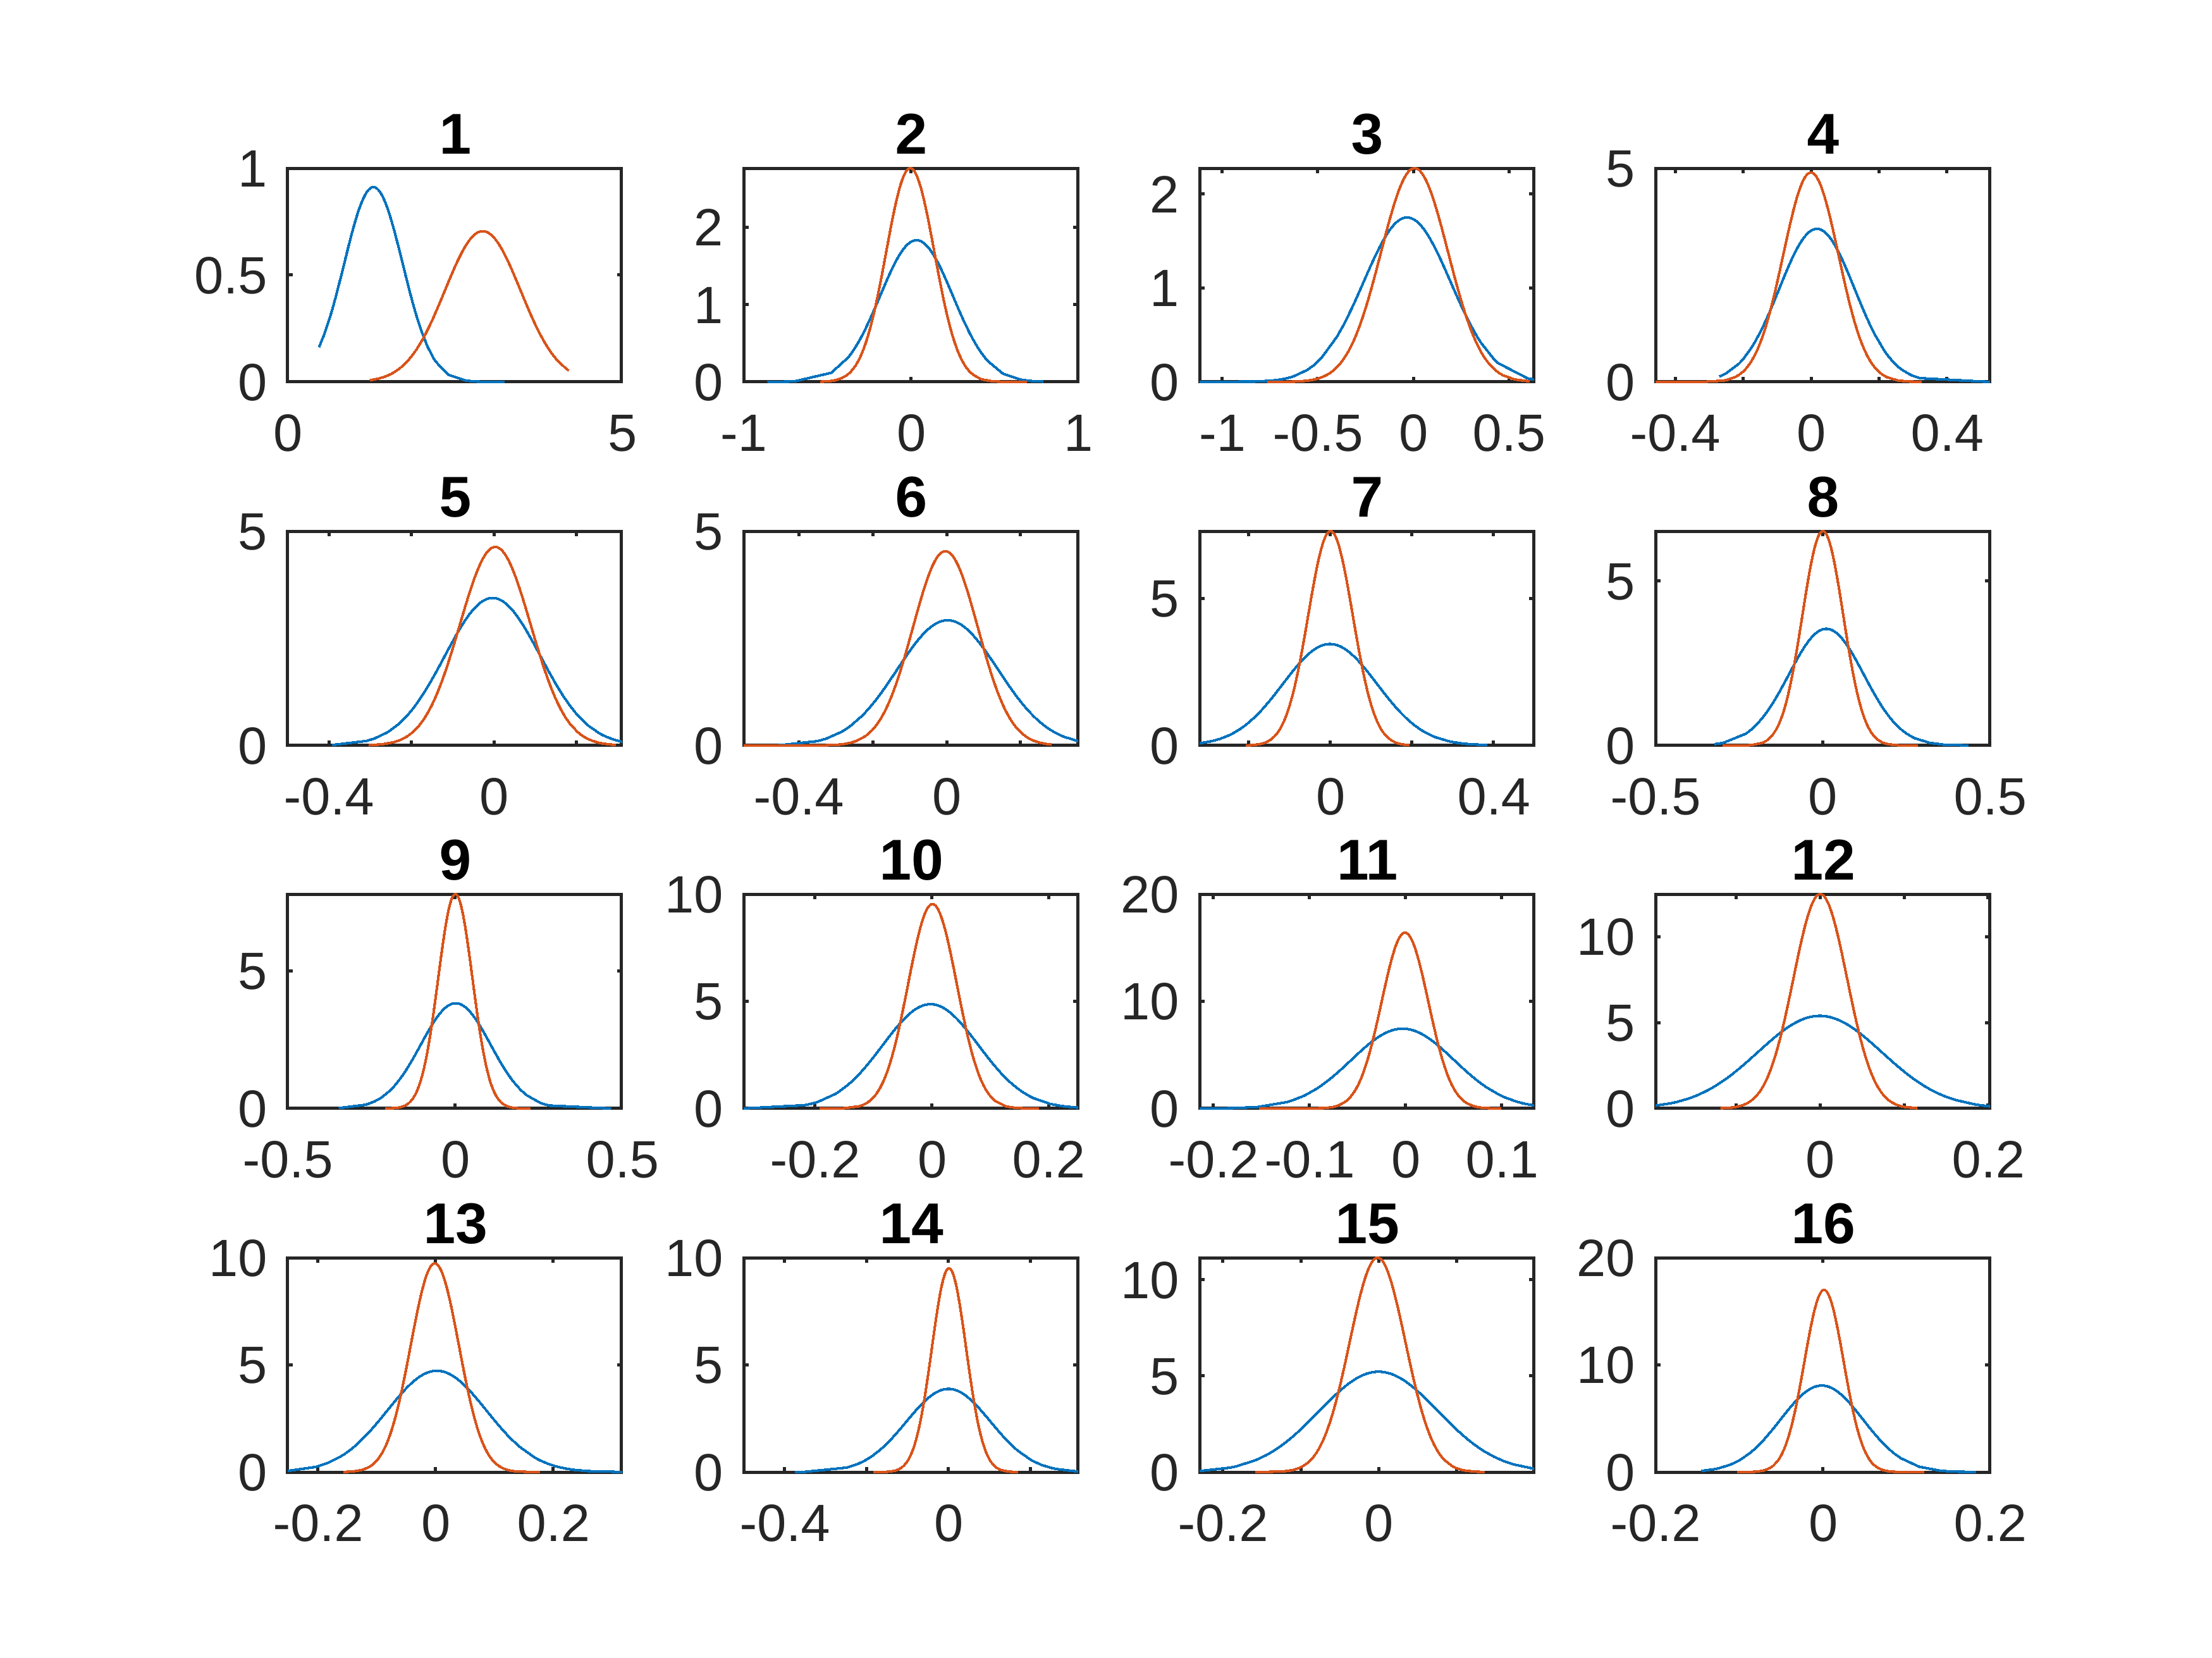


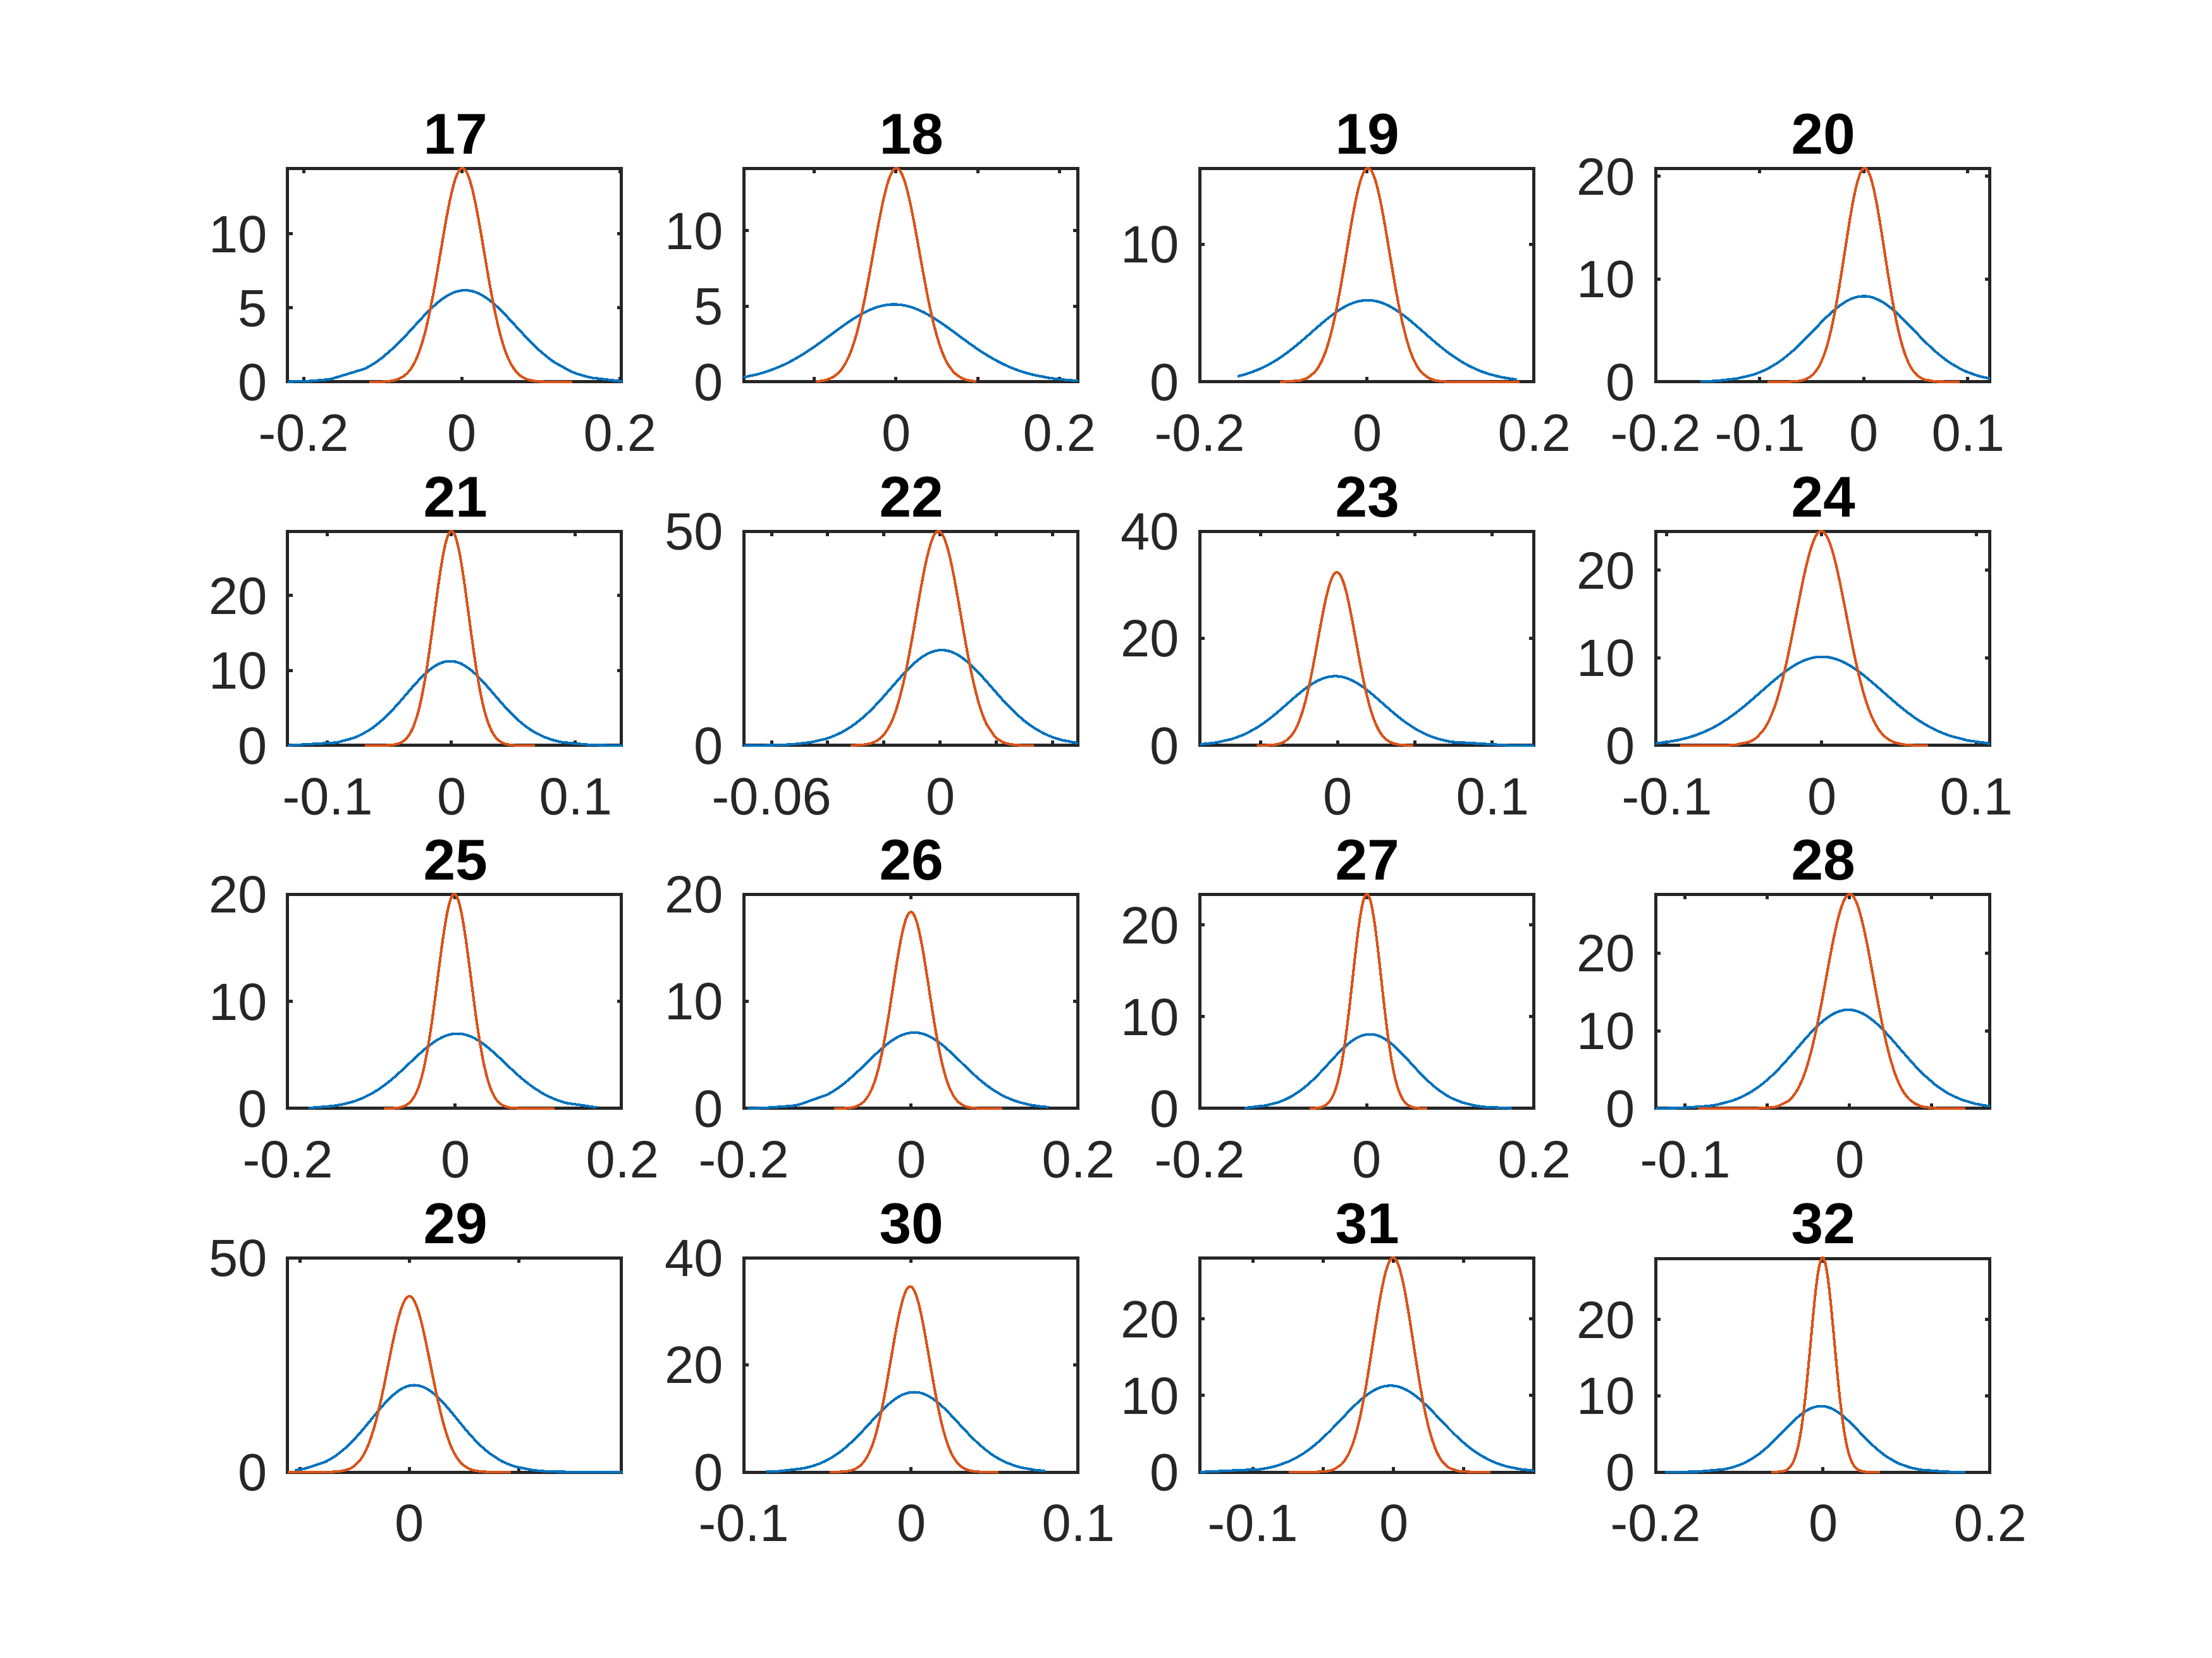

In [5]:
function P = P_XY(x,y)

C = cov(y);
mu = mean(y);
d = size(mu,1);

if(size(C,1)==1 &size(C,2)==1)
    A = exp(-(x-mu).*(x-mu)/(2*C));
else
    for o = 1:size(x,1)
        A(o) = exp(-0.5.*((x(o,:)-mu)*(C\(x(o,:)-mu).')));
    end
end
B = sqrt(det(C)*(2*pi)^d);
P = A./B;
end

n = size(x_cheetah_abs,2);
n_frame = 4;
for i=1:n
    k = mod(i,n/n_frame);
    if(k==0)
        k=n/n_frame;
    end
    if(k==1)
        figure()
    end
    subplot(n_frame,n_frame,k)
    a = sort(x_cheetah_abs(:,i));
    b = sort(x_grass_abs(:,i));
    plot(a,P_XY(a,a),b,P_XY(b,b))
    title(i)
end

<center>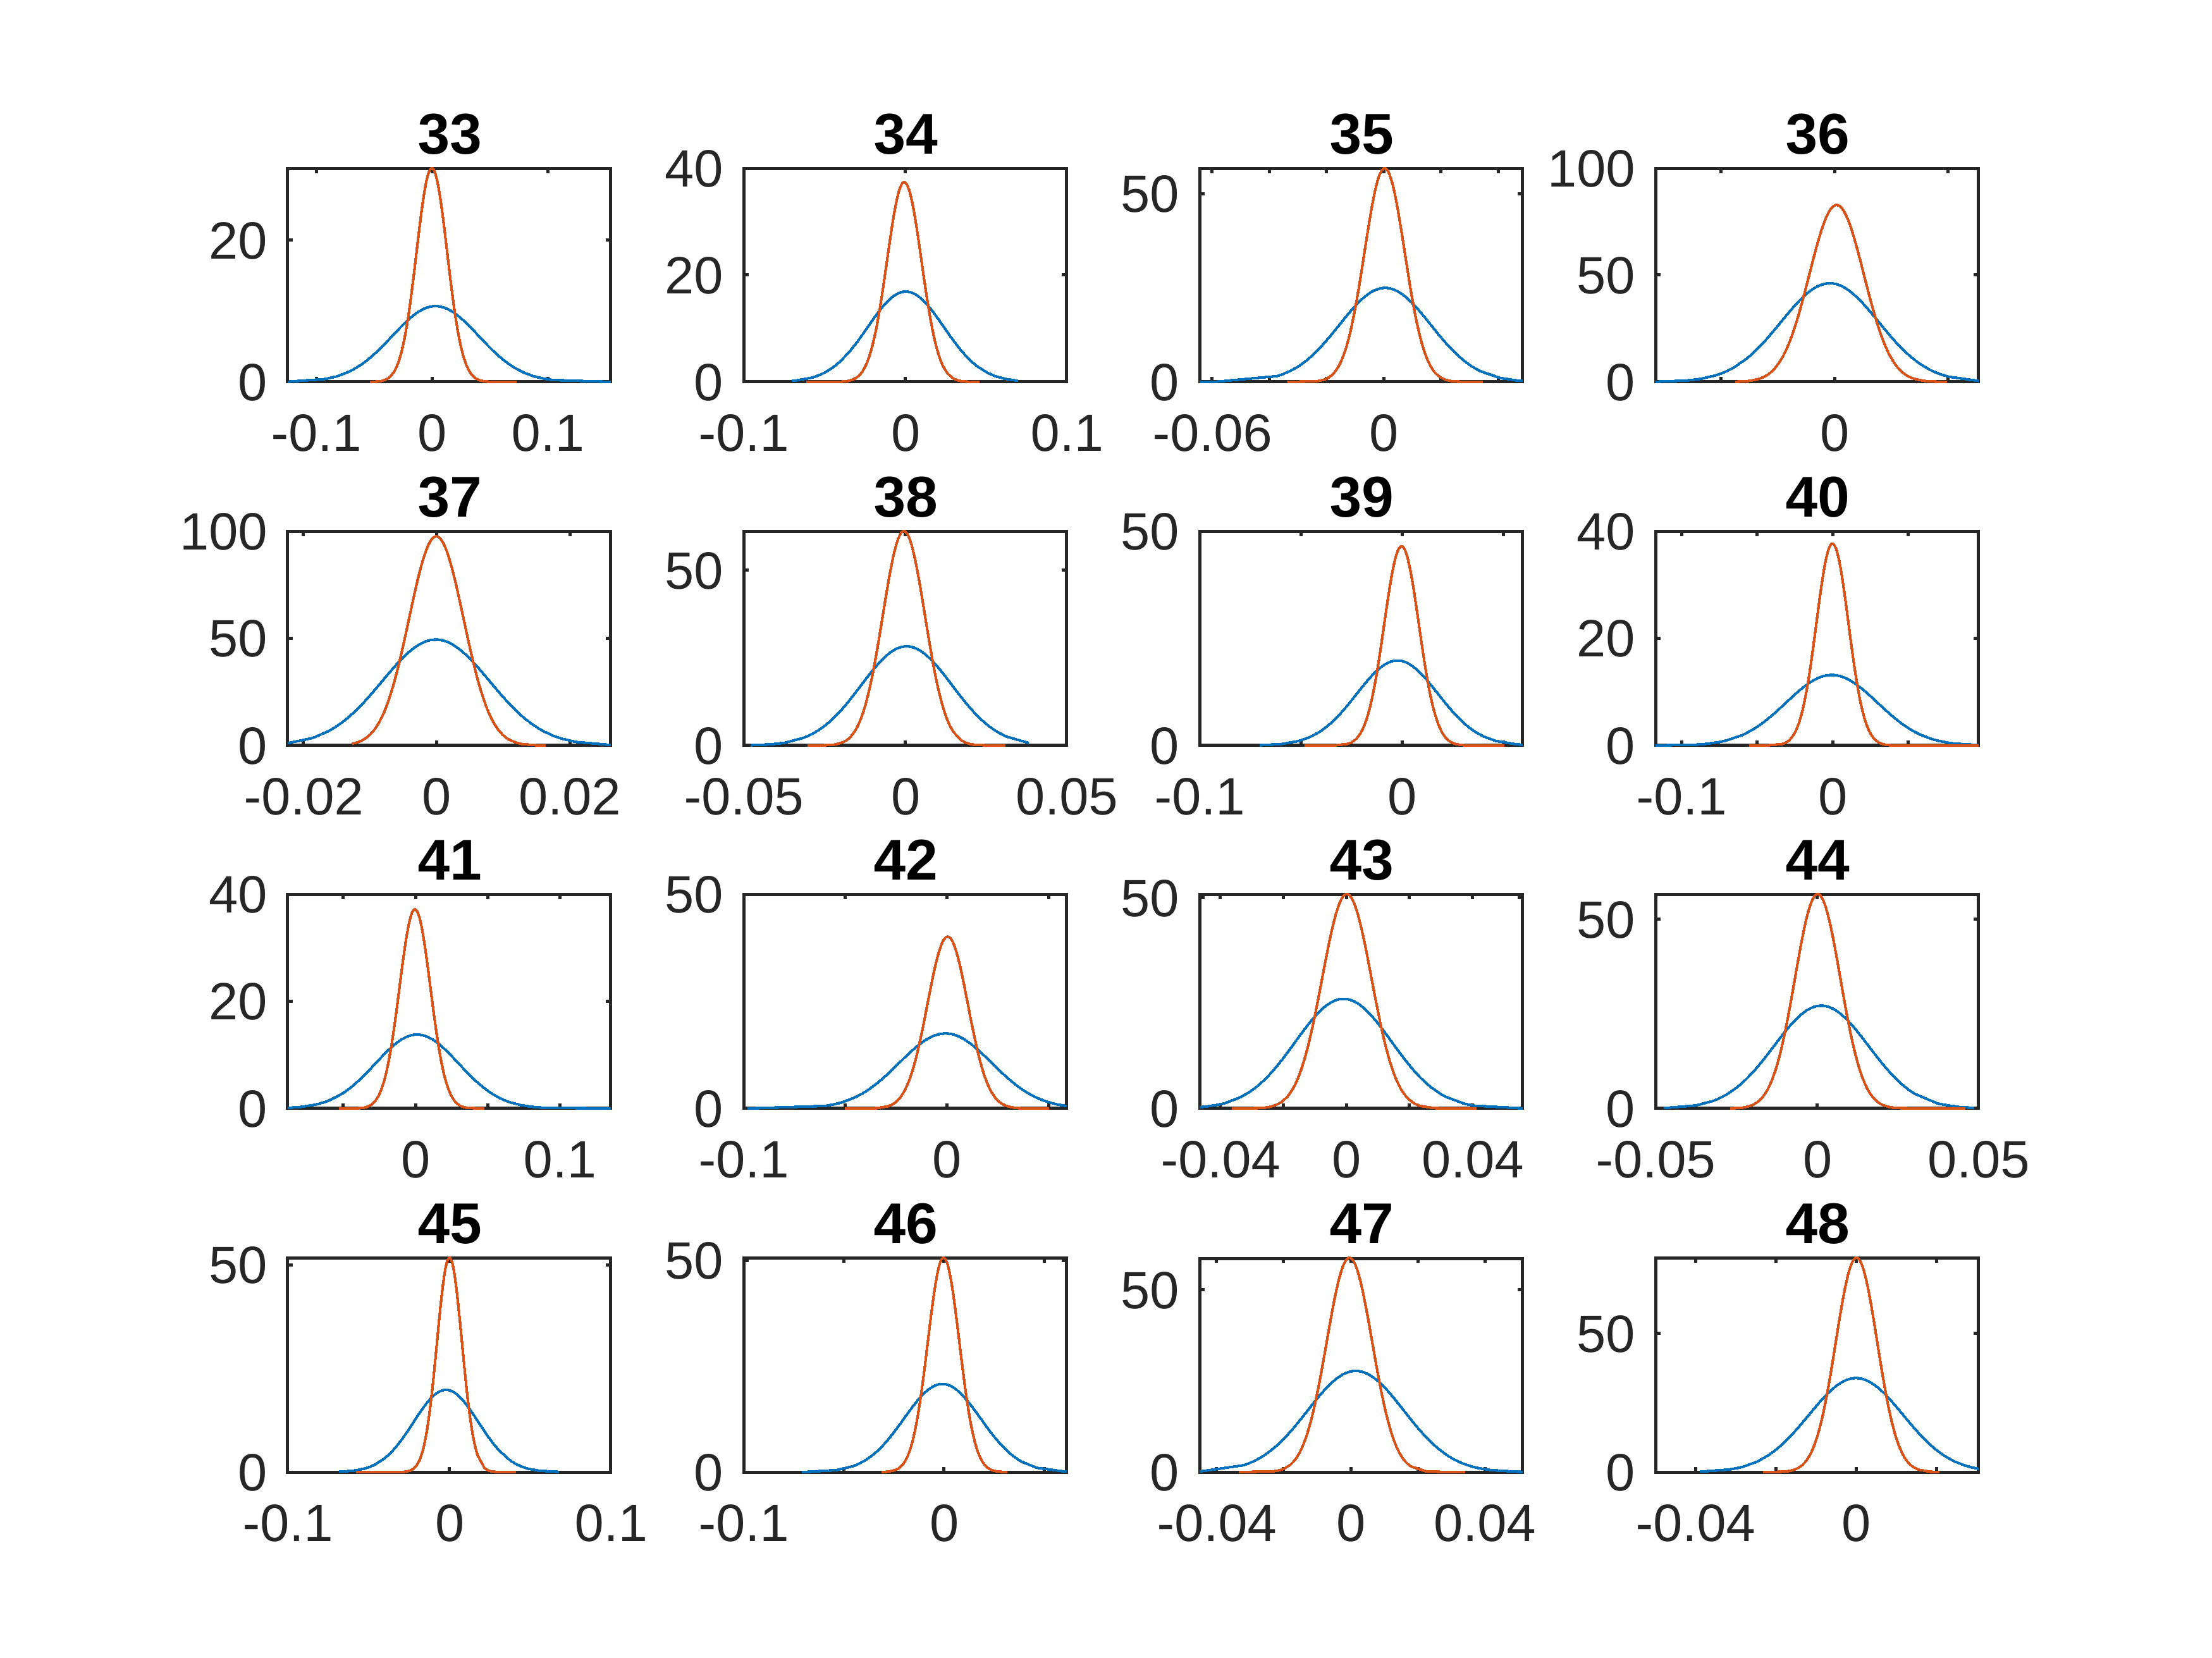</center>


<center>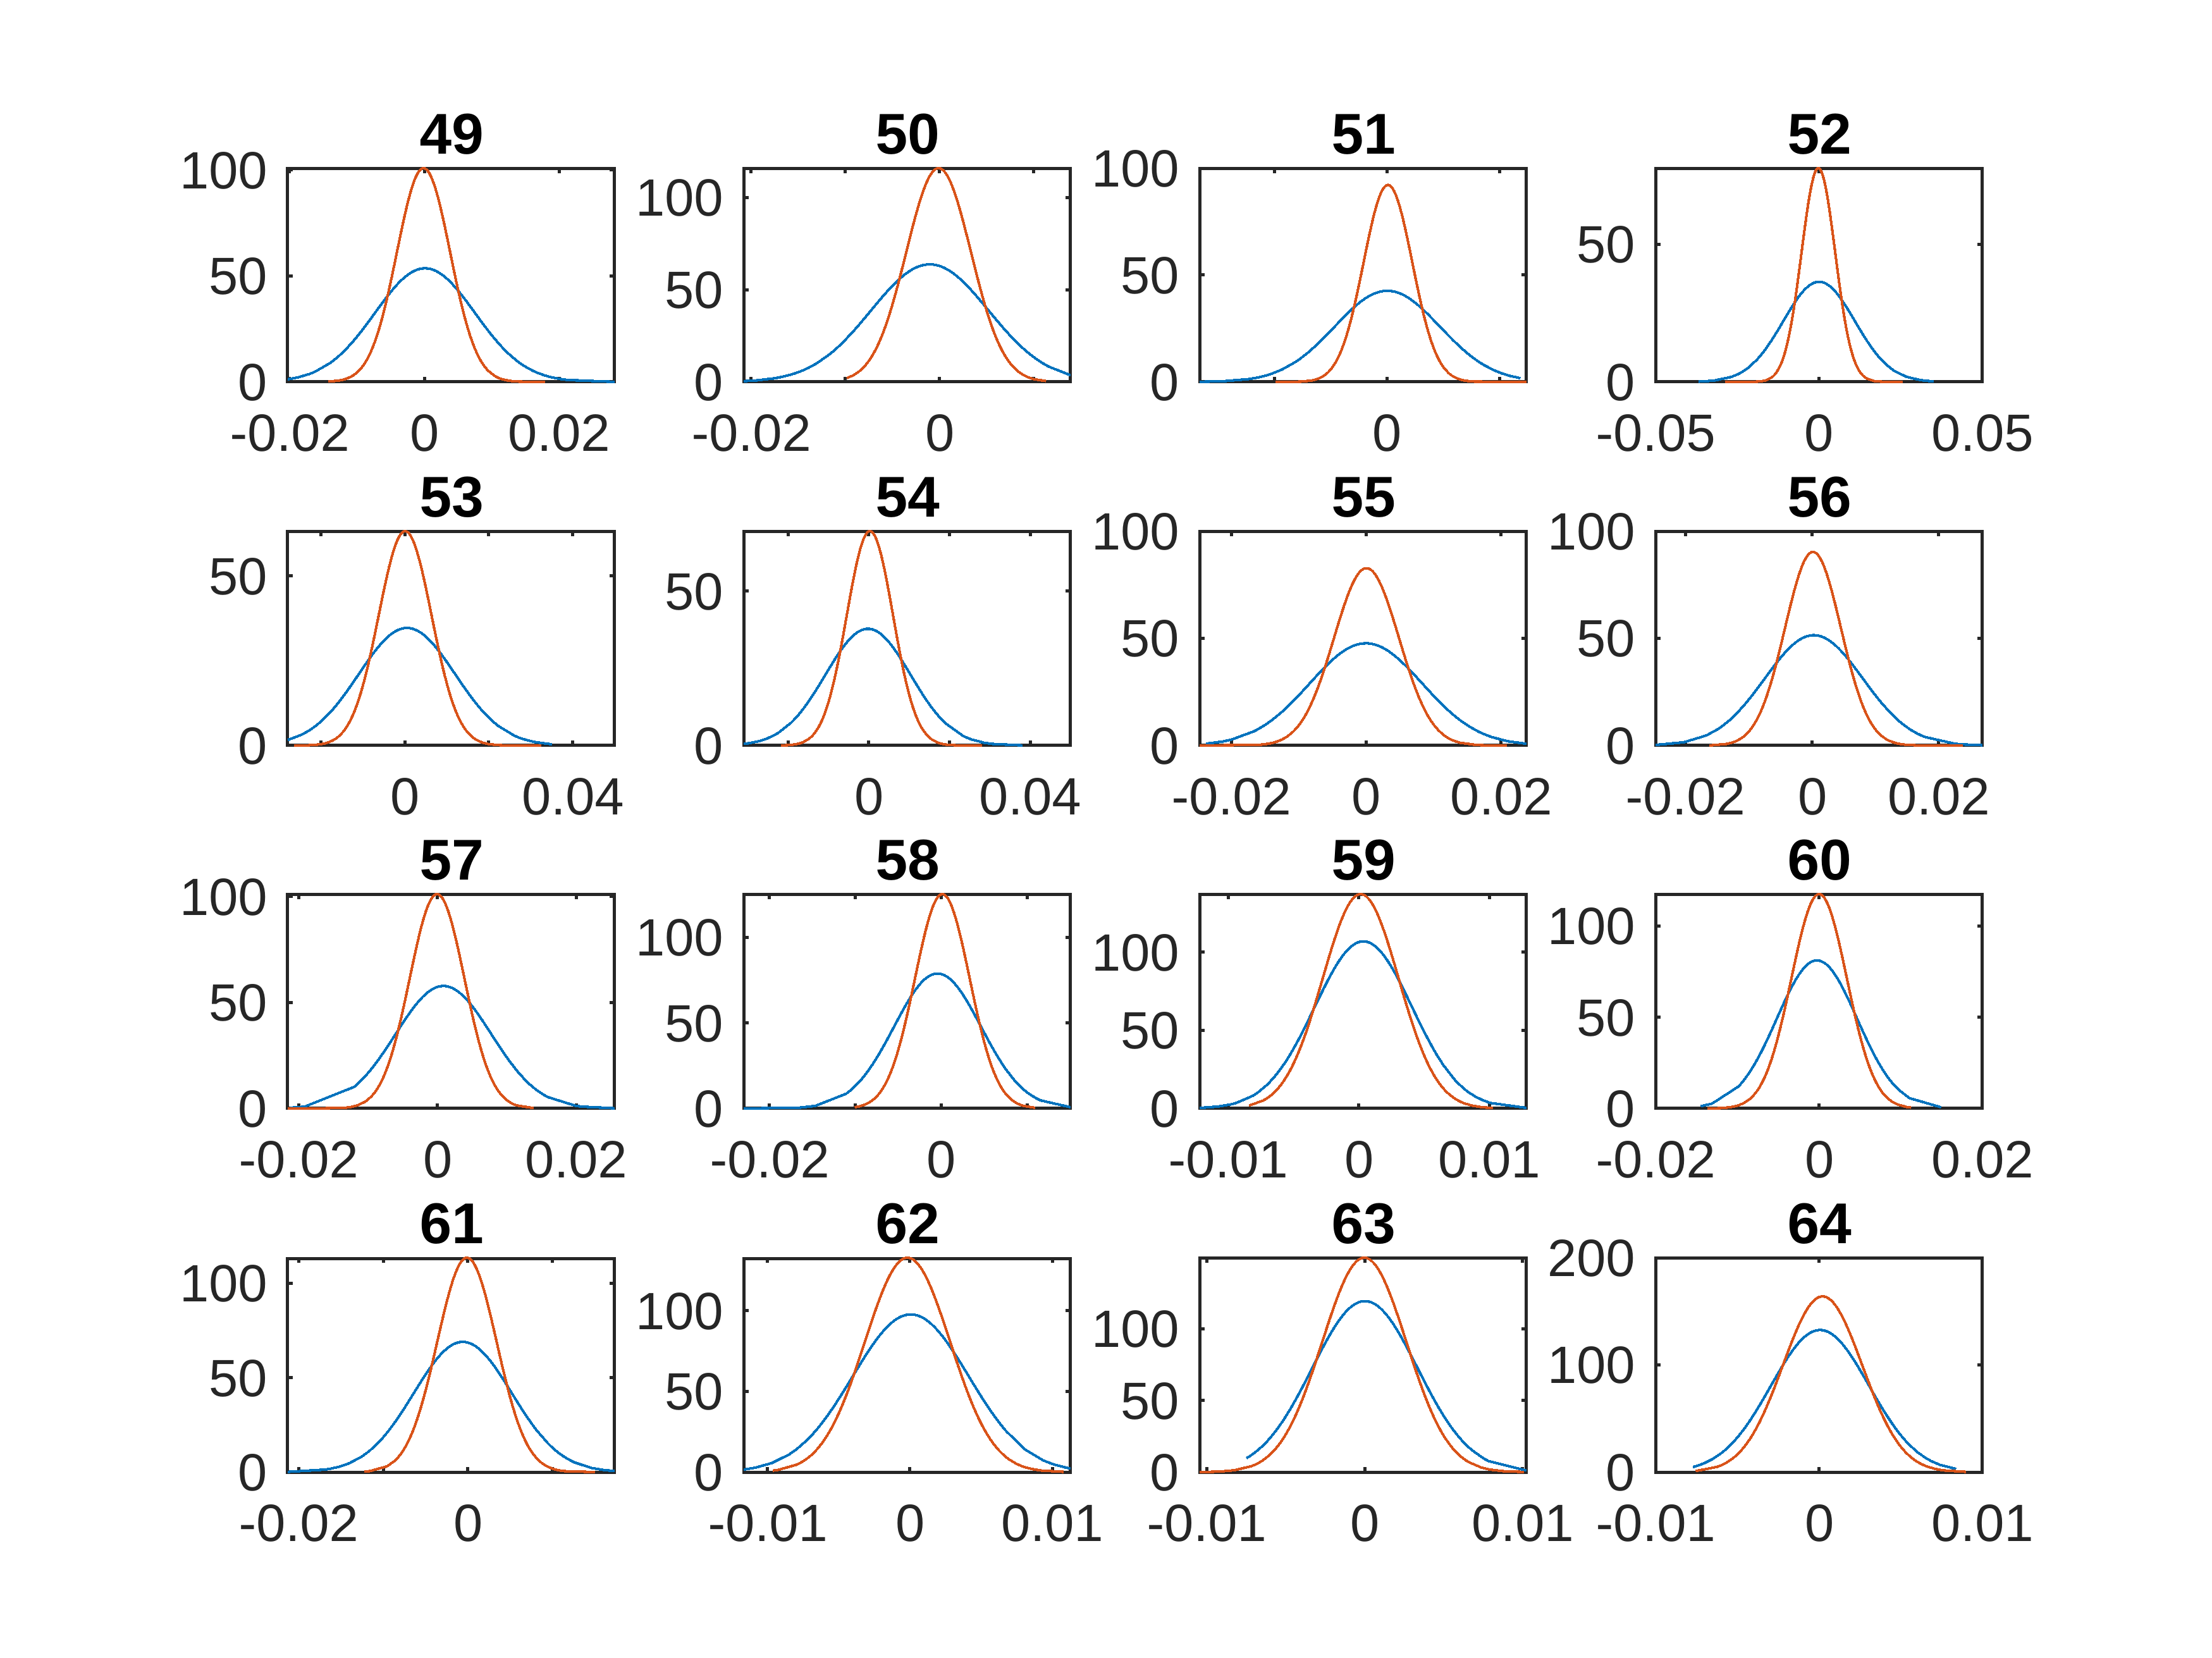</center>


BLUE \- Foreground (Cheetah), RED \- Background (Grass)


We will choose features such that the distribution is unique enough for each input to classify. This involes distribution to not overlap for ease of classification (difference between means are large and variance small) and the difference between the distribution must be large enough after considering prior probabilities in the maximum aposterior probability based decision making.


In [6]:
features = (1:n)';
mean_diff = zeros(n,1);
max_diff = zeros(n,1);

for j = 1:n
    a = (x_cheetah_abs(:,j));
    b = (x_grass_abs(:,j));
    mean_diff(j) = abs(mean(a)-mean(b));
end

results = table(features, mean_diff,'VariableNames', {'Feature', 'Mean_Difference'});

sortedByMean = sortrows(results, 'Mean_Difference', 'descend');
disp('Sorted by Mean Difference (Descending):')

Sorted by Mean Difference (Descending):

In [7]:
disp(sortedByMean)

    Feature    Mean_Difference
    _______    _______________
       1             1.6339   
       3           0.038987   
       2           0.037295   
       4           0.017765   
       8            0.01037   
       5          0.0064698   
       6          0.0059967   
      26          0.0039823   
      25          0.0036181   
      27          0.0036008   
      13          0.0035159   
      17          0.0034687   
      10          0.0032688   
      33          0.0031464   
      16          0.0027015   
      18          0.0027014   
      11           0.002471   
      30          0.0024068   
      29          0.0022551   
      45          0.0021583   
      39           0.002041   
      47          0.0018722   
      32          0.0018676   
      31          0.0018196   
      41          0.0014566   
      14          0.0013253   
      15          0.0013183   
       7           0.001311   
      36          0.0011934   
      22           0.001124   
      44


By that logic, best features are 1,7,12,18,25,30,40,50 and worst features are 2,3,4,5,61,62,63,64


8 Best Features



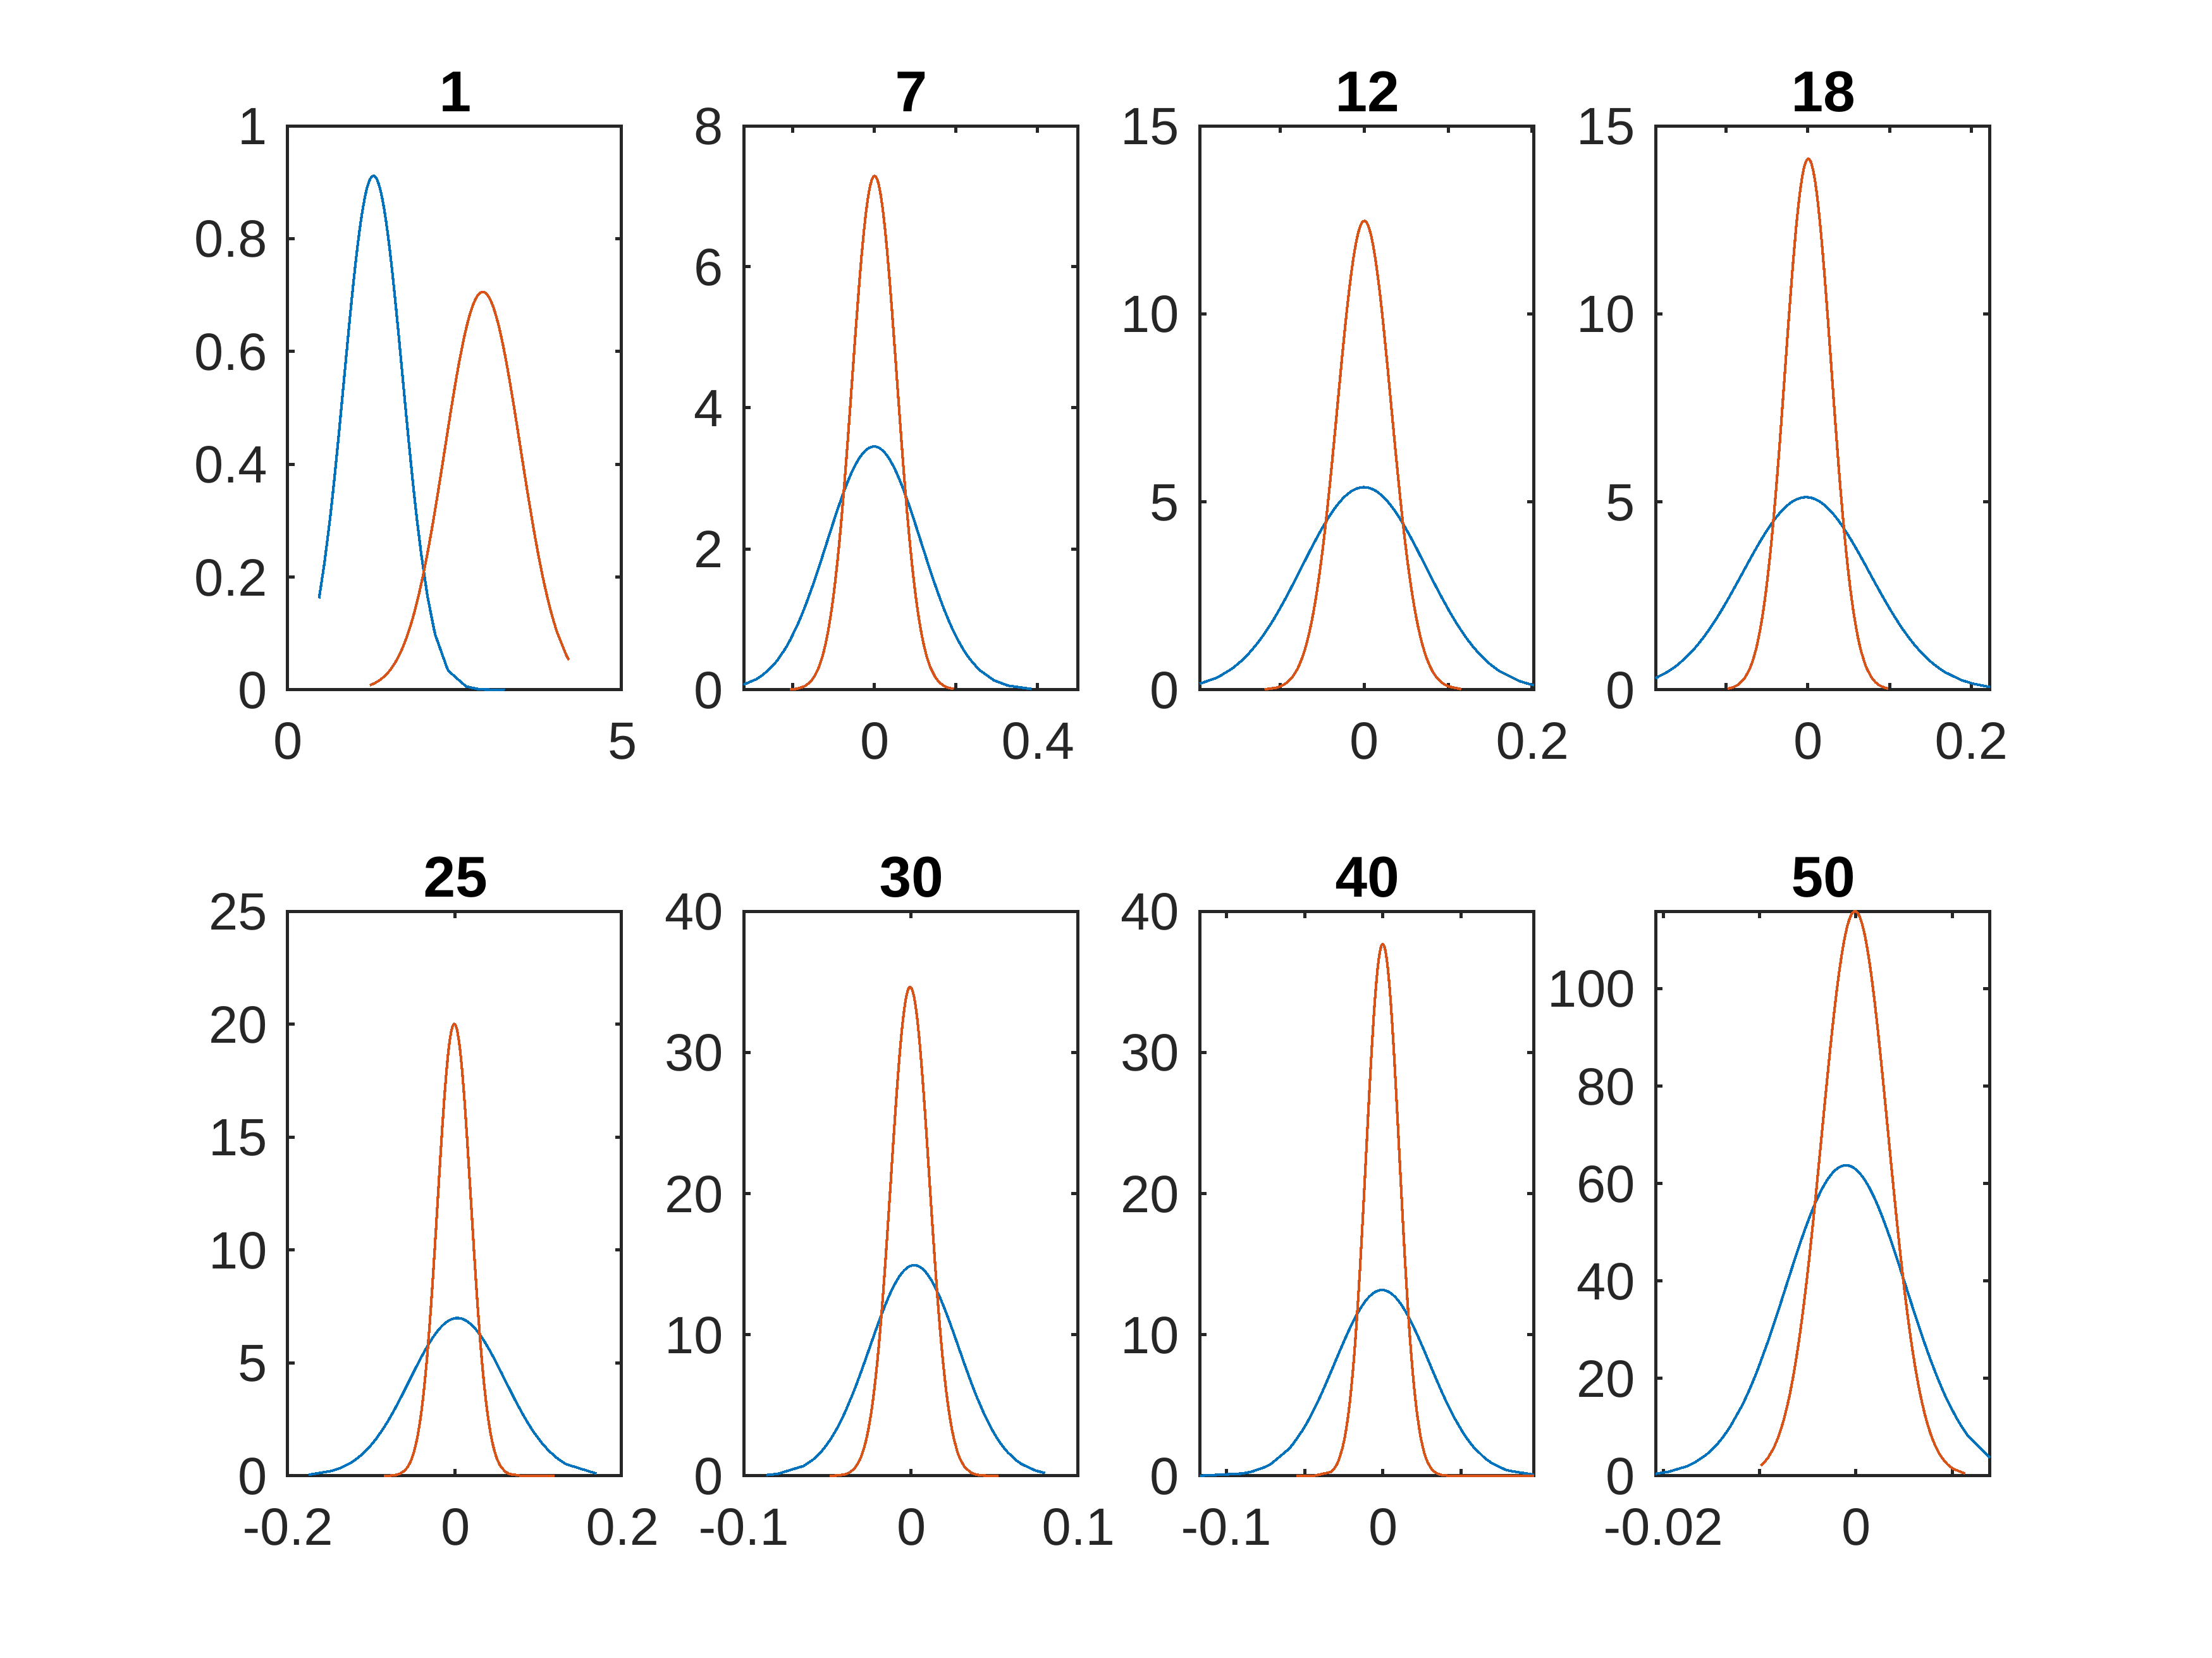

In [8]:
n_row = 2;
k = 0;
best_features = [1,7,12,18,25,30,40,50];
for i= best_features
    k=k+1;
    subplot(n_row,8/n_row,k)
    a = sort(x_cheetah_abs(:,i));
    b = sort(x_grass_abs(:,i));
    plot(a,P_XY(a,a),b,P_XY(b,b))
    title(i)
end


8 Worst Features



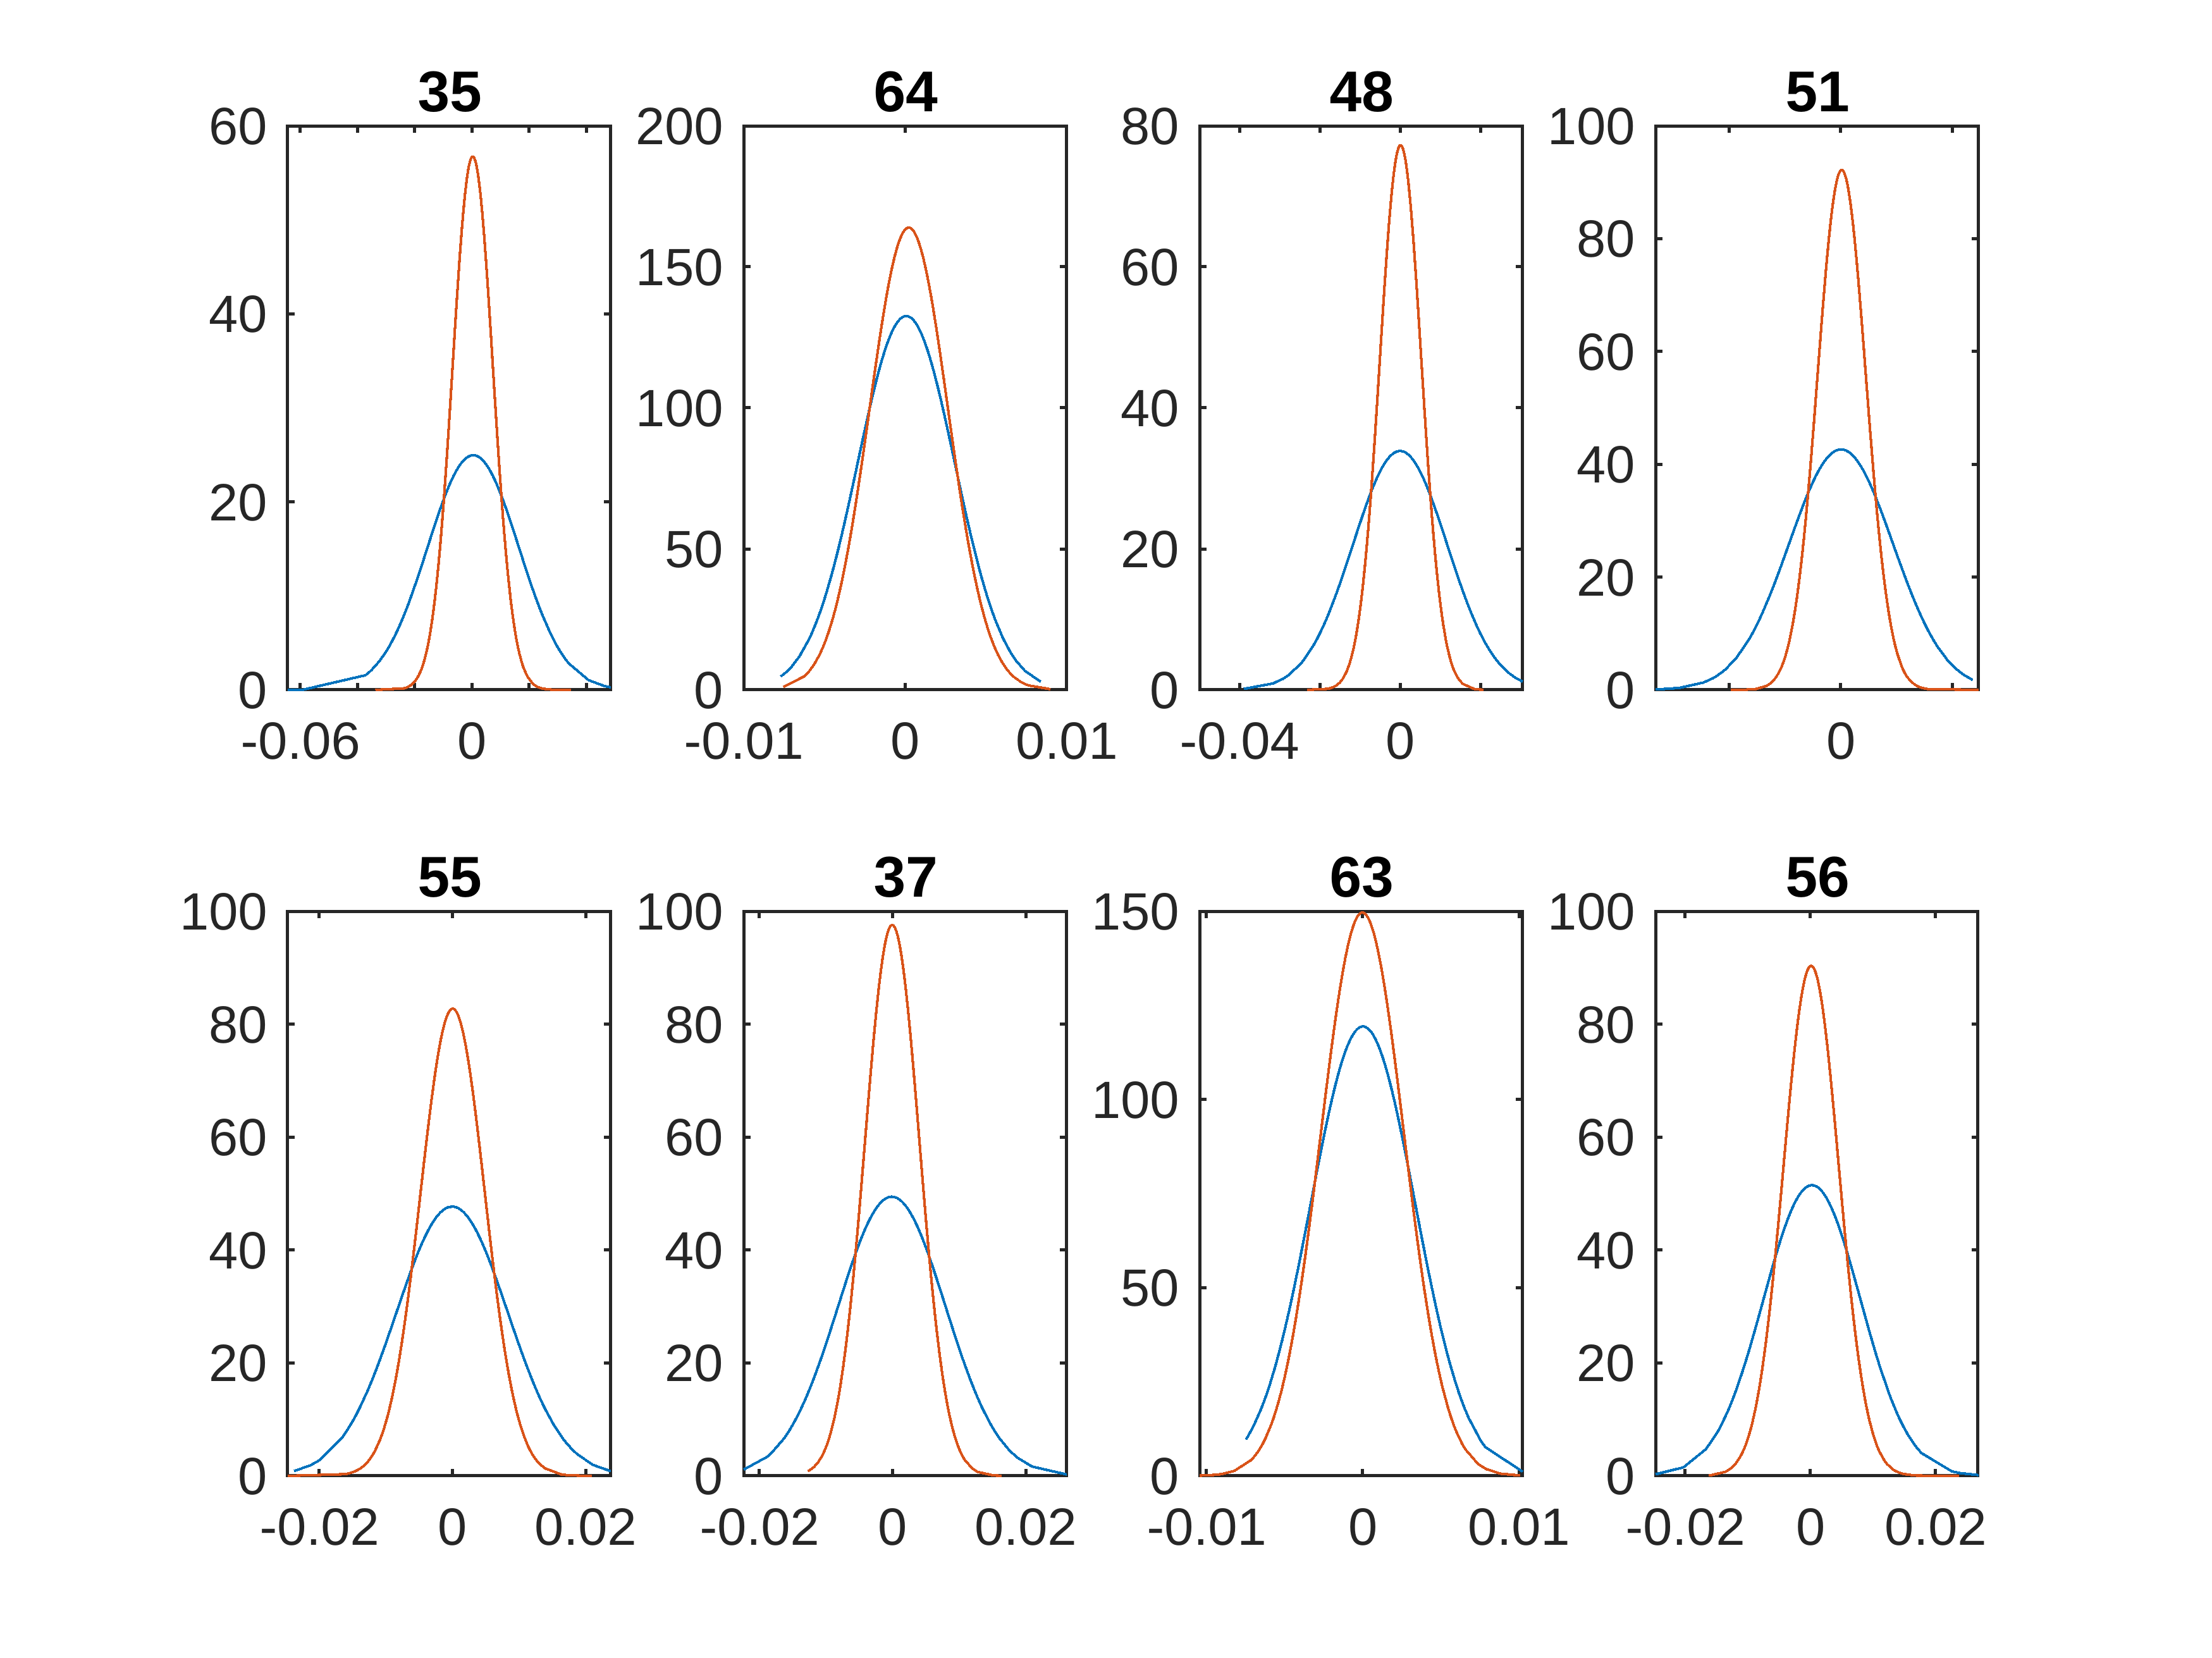

In [9]:
k=0;
figure;

worst_features = [35,64,48,51,55,37,63,56];%[2,3,4,5,61,62,63,64];
for i= worst_features
    k=k+1;
    subplot(n_row,8/n_row,k)
    a = sort(x_cheetah_abs(:,i));
    b = sort(x_grass_abs(:,i));
    plot(a,P_XY(a,a),b,P_XY(b,b))
    title(i)
end


Importing and preprocessing the image



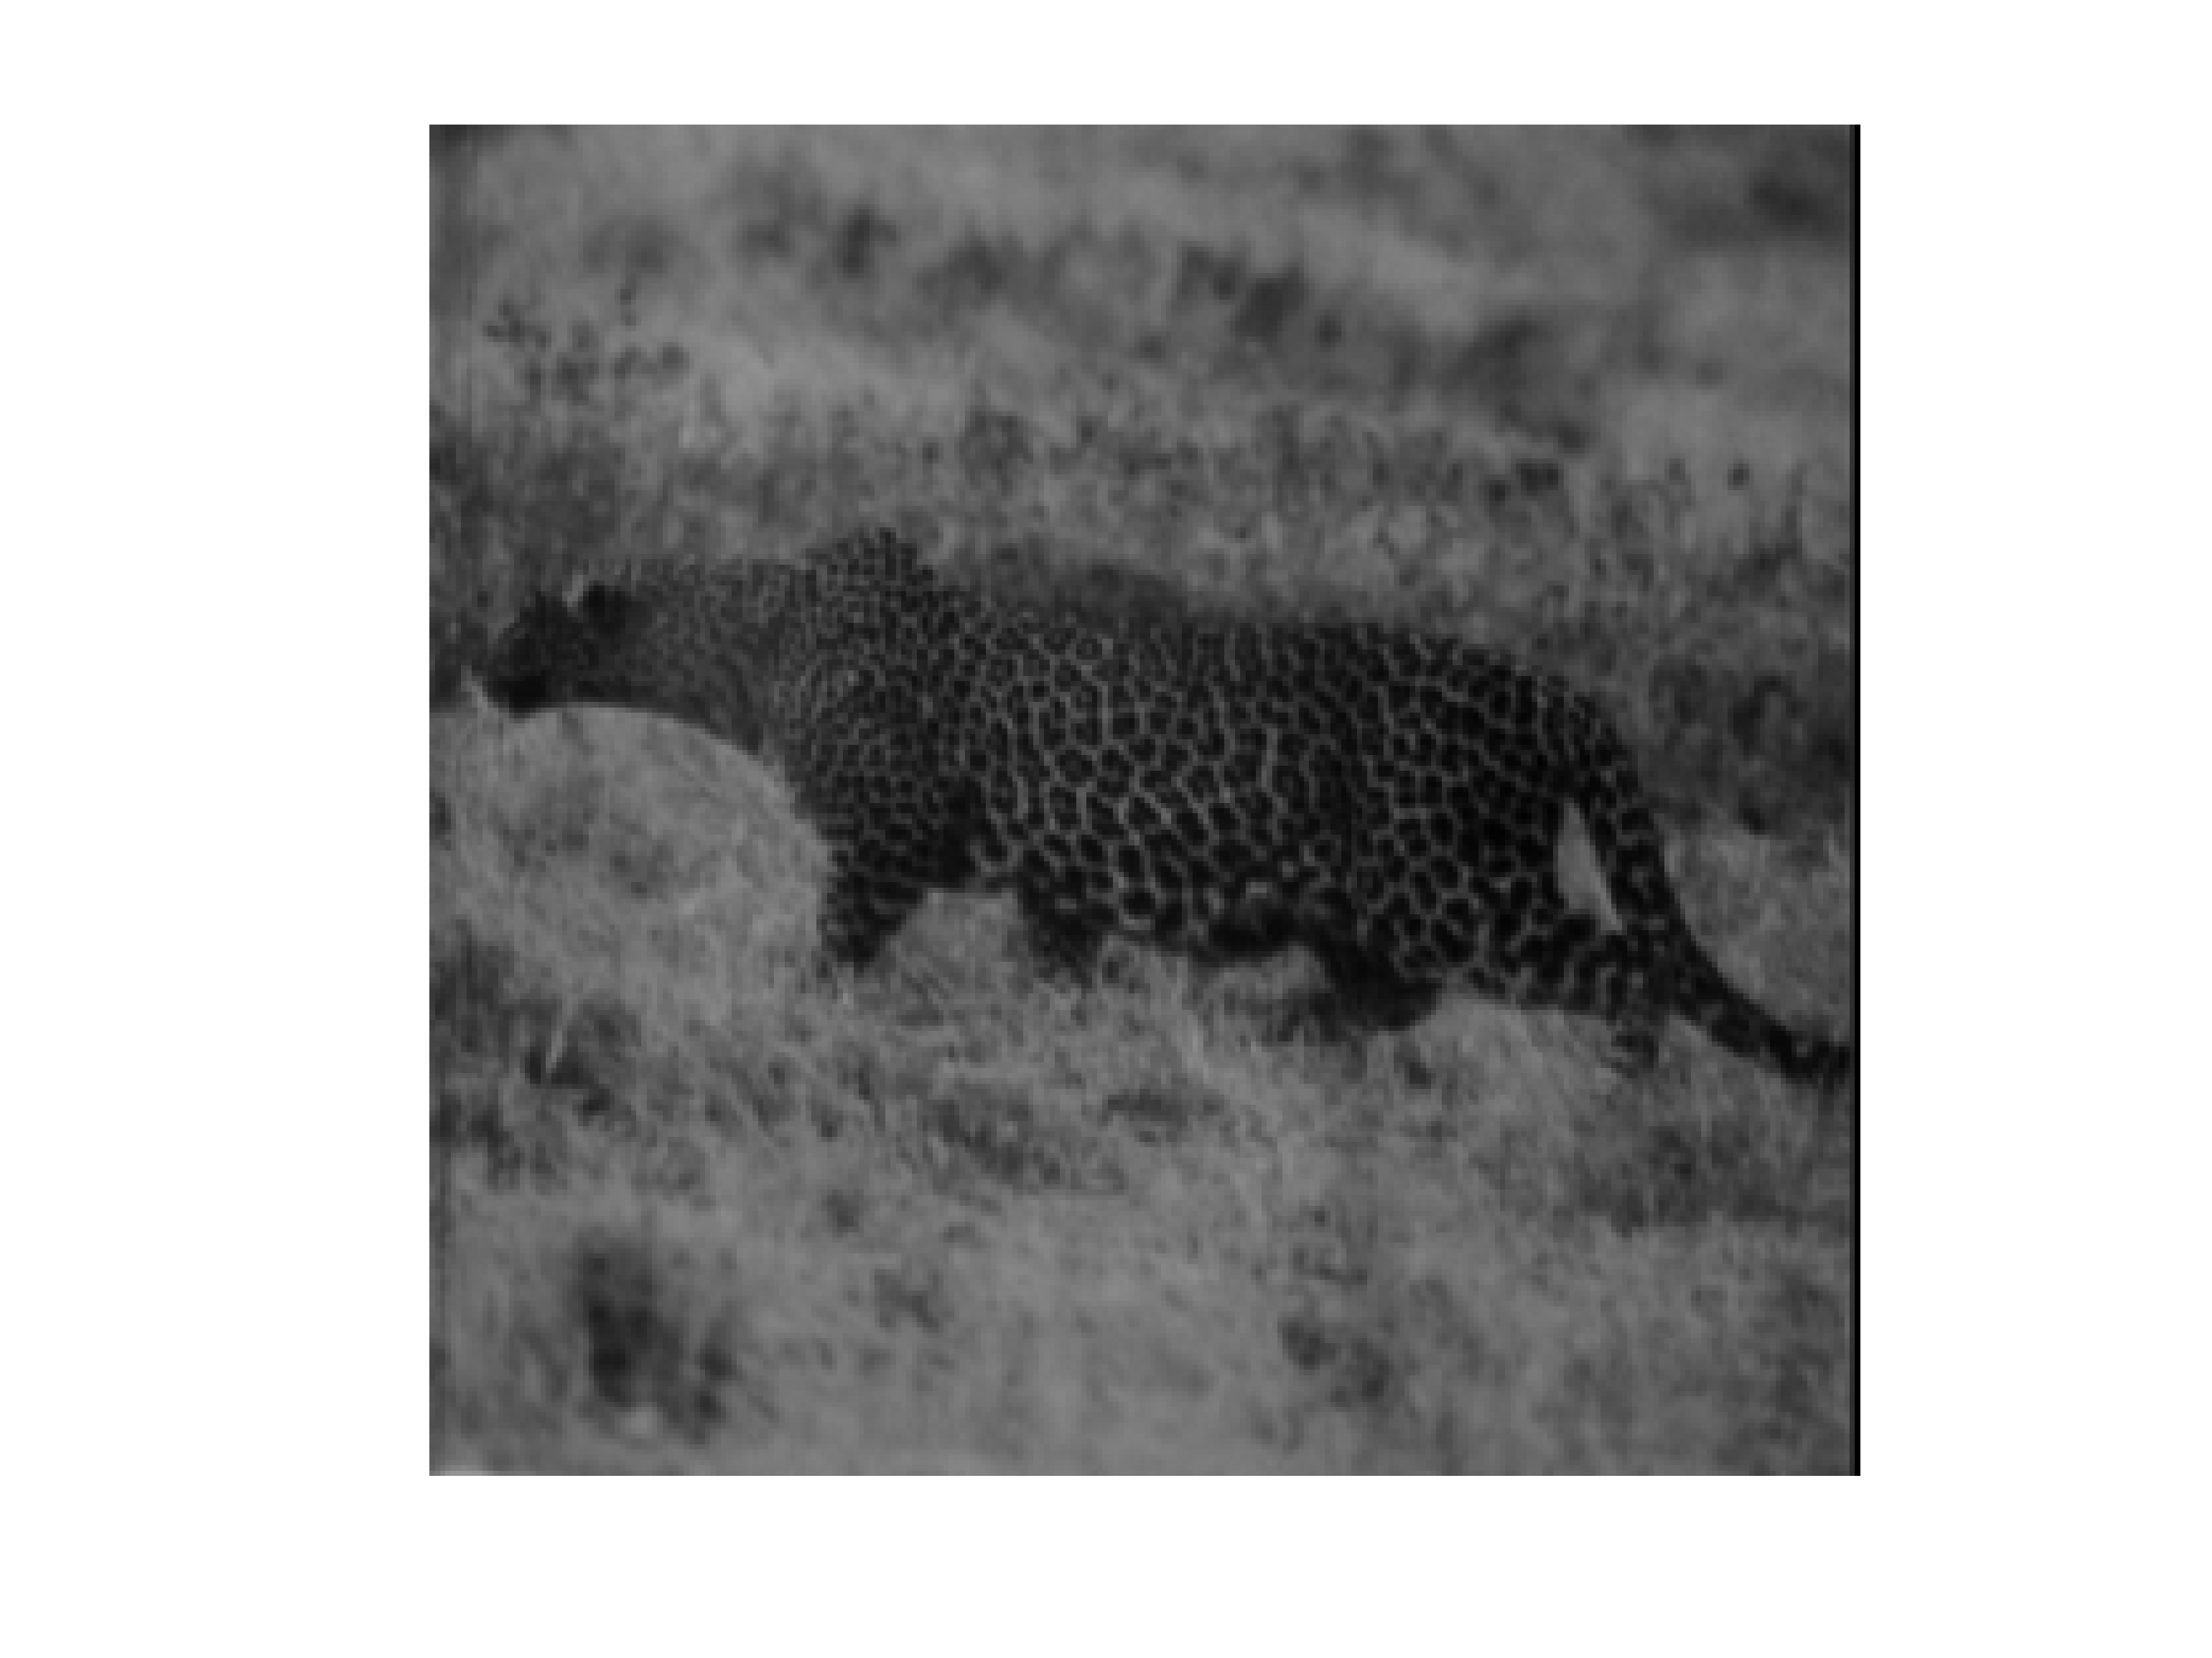

In [10]:
I = imread("cheetah.bmp");
figure
imshow(I)


Ground truth


In [11]:
I_ground = imread("cheetah_mask.bmp");
I_ground_double = im2double(I_ground);


Padding the edges of the image for sliding window


In [12]:
image = im2double(I); %255x270
win_dim = 8; % 8x8
pad_x_dir = win_dim/2;
pad_y_dir = win_dim/2;
I_pad = padarray(image,[pad_x_dir,pad_y_dir],"replicate") % 261x278 for 8x8 window with top left filter as pixel filter.

I_pad = 263x278
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059    0.5176    0.5294
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059   


DCT matrix to array \- zig zag vector


In [13]:
dct_vec_order = [1    2    6    7    15    16    28    29;
3    5    8    14    17    27    30    43;
4    9    13    18    26    31    42    44;
10    12    19    25    32    41    45    54;
11    20    24    33    40    46    53    55;
21    23    34    39    47    52    56    61;
22    35    38    48    51    57    60    62;
36    37    49    50    58    59    63    64];


Sliding window on the image and extracting the DCT matrix as array


In [14]:
k=0;
feature = ones(size(image,1)*size(image,2),win_dim*win_dim);
fl = zeros(1,win_dim*win_dim);
for i = 1:size(image,1)
    for j = 1:size(image,2)
        image_dct(i:i+win_dim-1,j:j+win_dim-1)=dct2(I_pad(i:i+win_dim-1,j:j+win_dim-1));
        k=k+1;
        fl(dct_vec_order) = image_dct(i:i+win_dim-1,j:j+win_dim-1);
        feature(k,:) = fl;
    end
end


Obtaining feature X from the flattened DCT matrix


In [15]:
X = feature;


Calculating Bayes Decision Rule for classification based on prior probabilities and


In [16]:
function [P_cheetah_given_x_prop,P_grass_given_x_prop,A] = BDR (X,X_cheetah,X_grass,P_cheetah,P_grass)
    P_cheetah_given_x_prop = P_XY(X,X_cheetah).*P_cheetah; % Value proportional to Probability that class is cheetah given feature x
    P_grass_given_x_prop = P_XY(X,X_grass).*P_grass;          %  Value proportional to Probability that class is cheetah given feature x
    A = (P_cheetah_given_x_prop>P_grass_given_x_prop); % Action - segmentation based on Bayes Decision Rule - choose class with more conditional probability given the feature to reduce risk.
end


Considering all 64 features for classification


In [17]:
[P_cheetah_given_x_prop,P_grass_given_x_prop,Action1] = BDR (X,x_cheetah_abs,x_grass_abs,P_cheetah,P_grass);


Plotting the mask



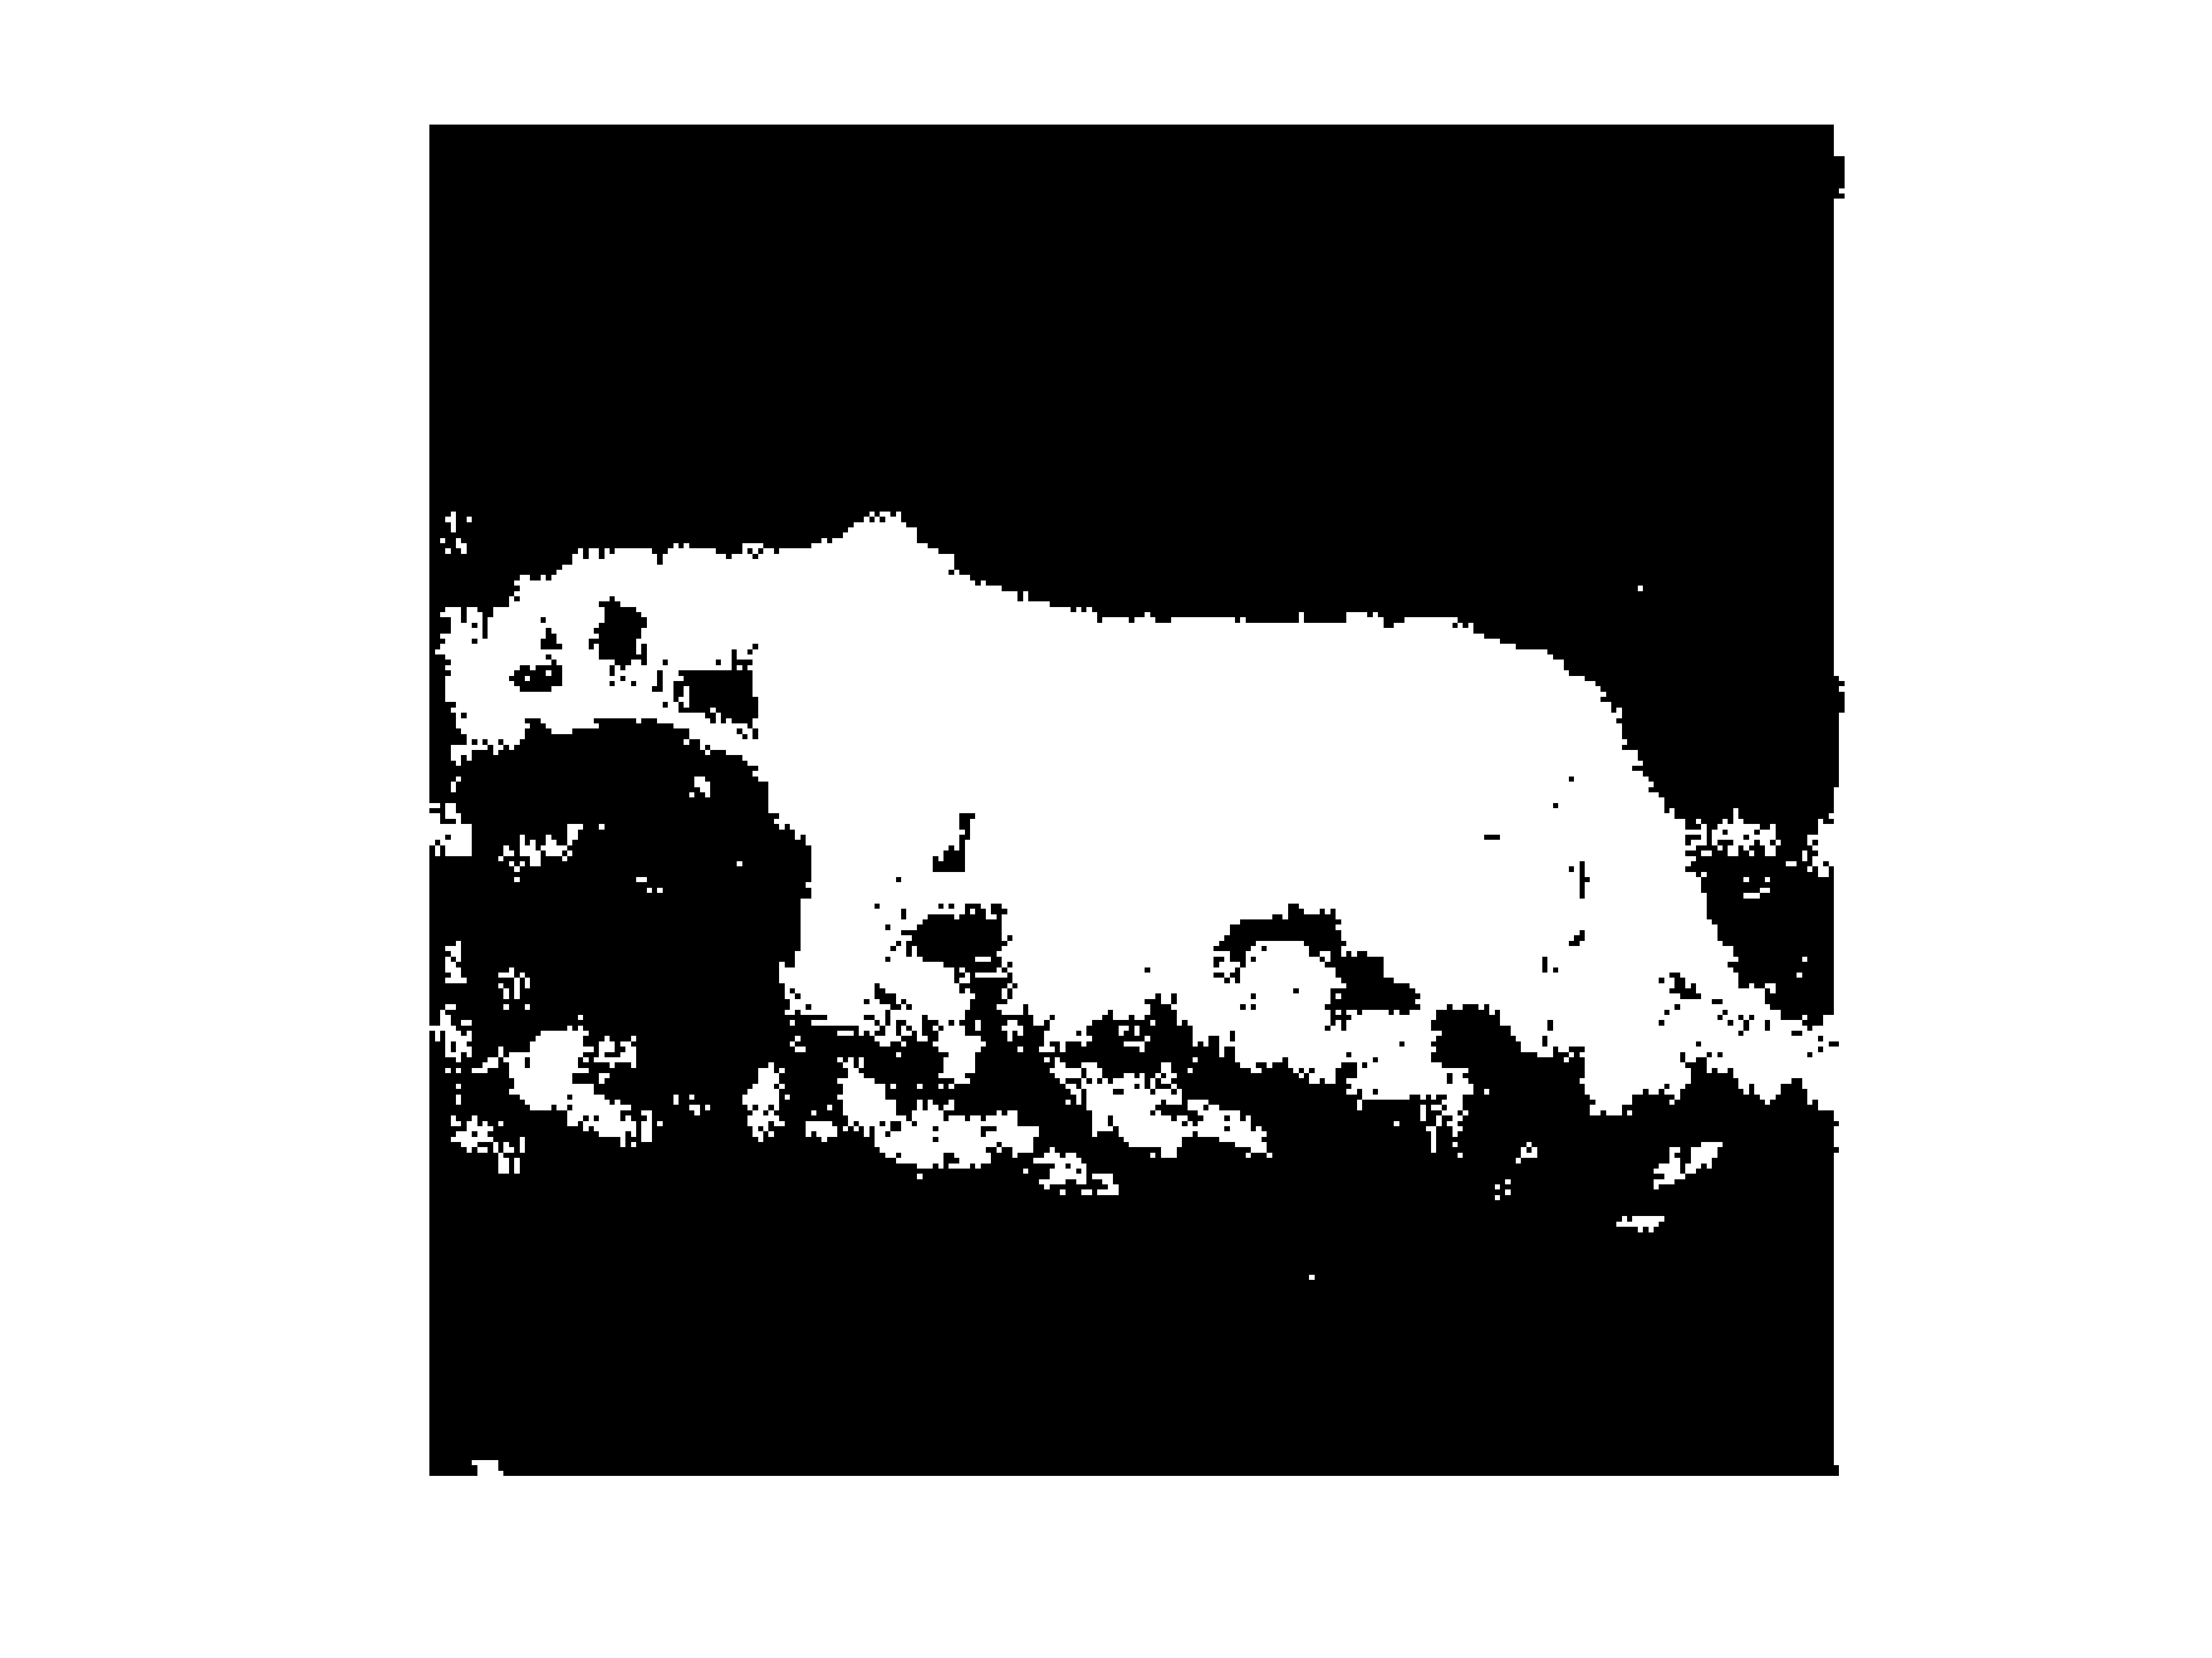

In [18]:
mask = reshape(Action1,size(image,2),[])';
figure
imshow(mask)


Comparison of result with ground truth



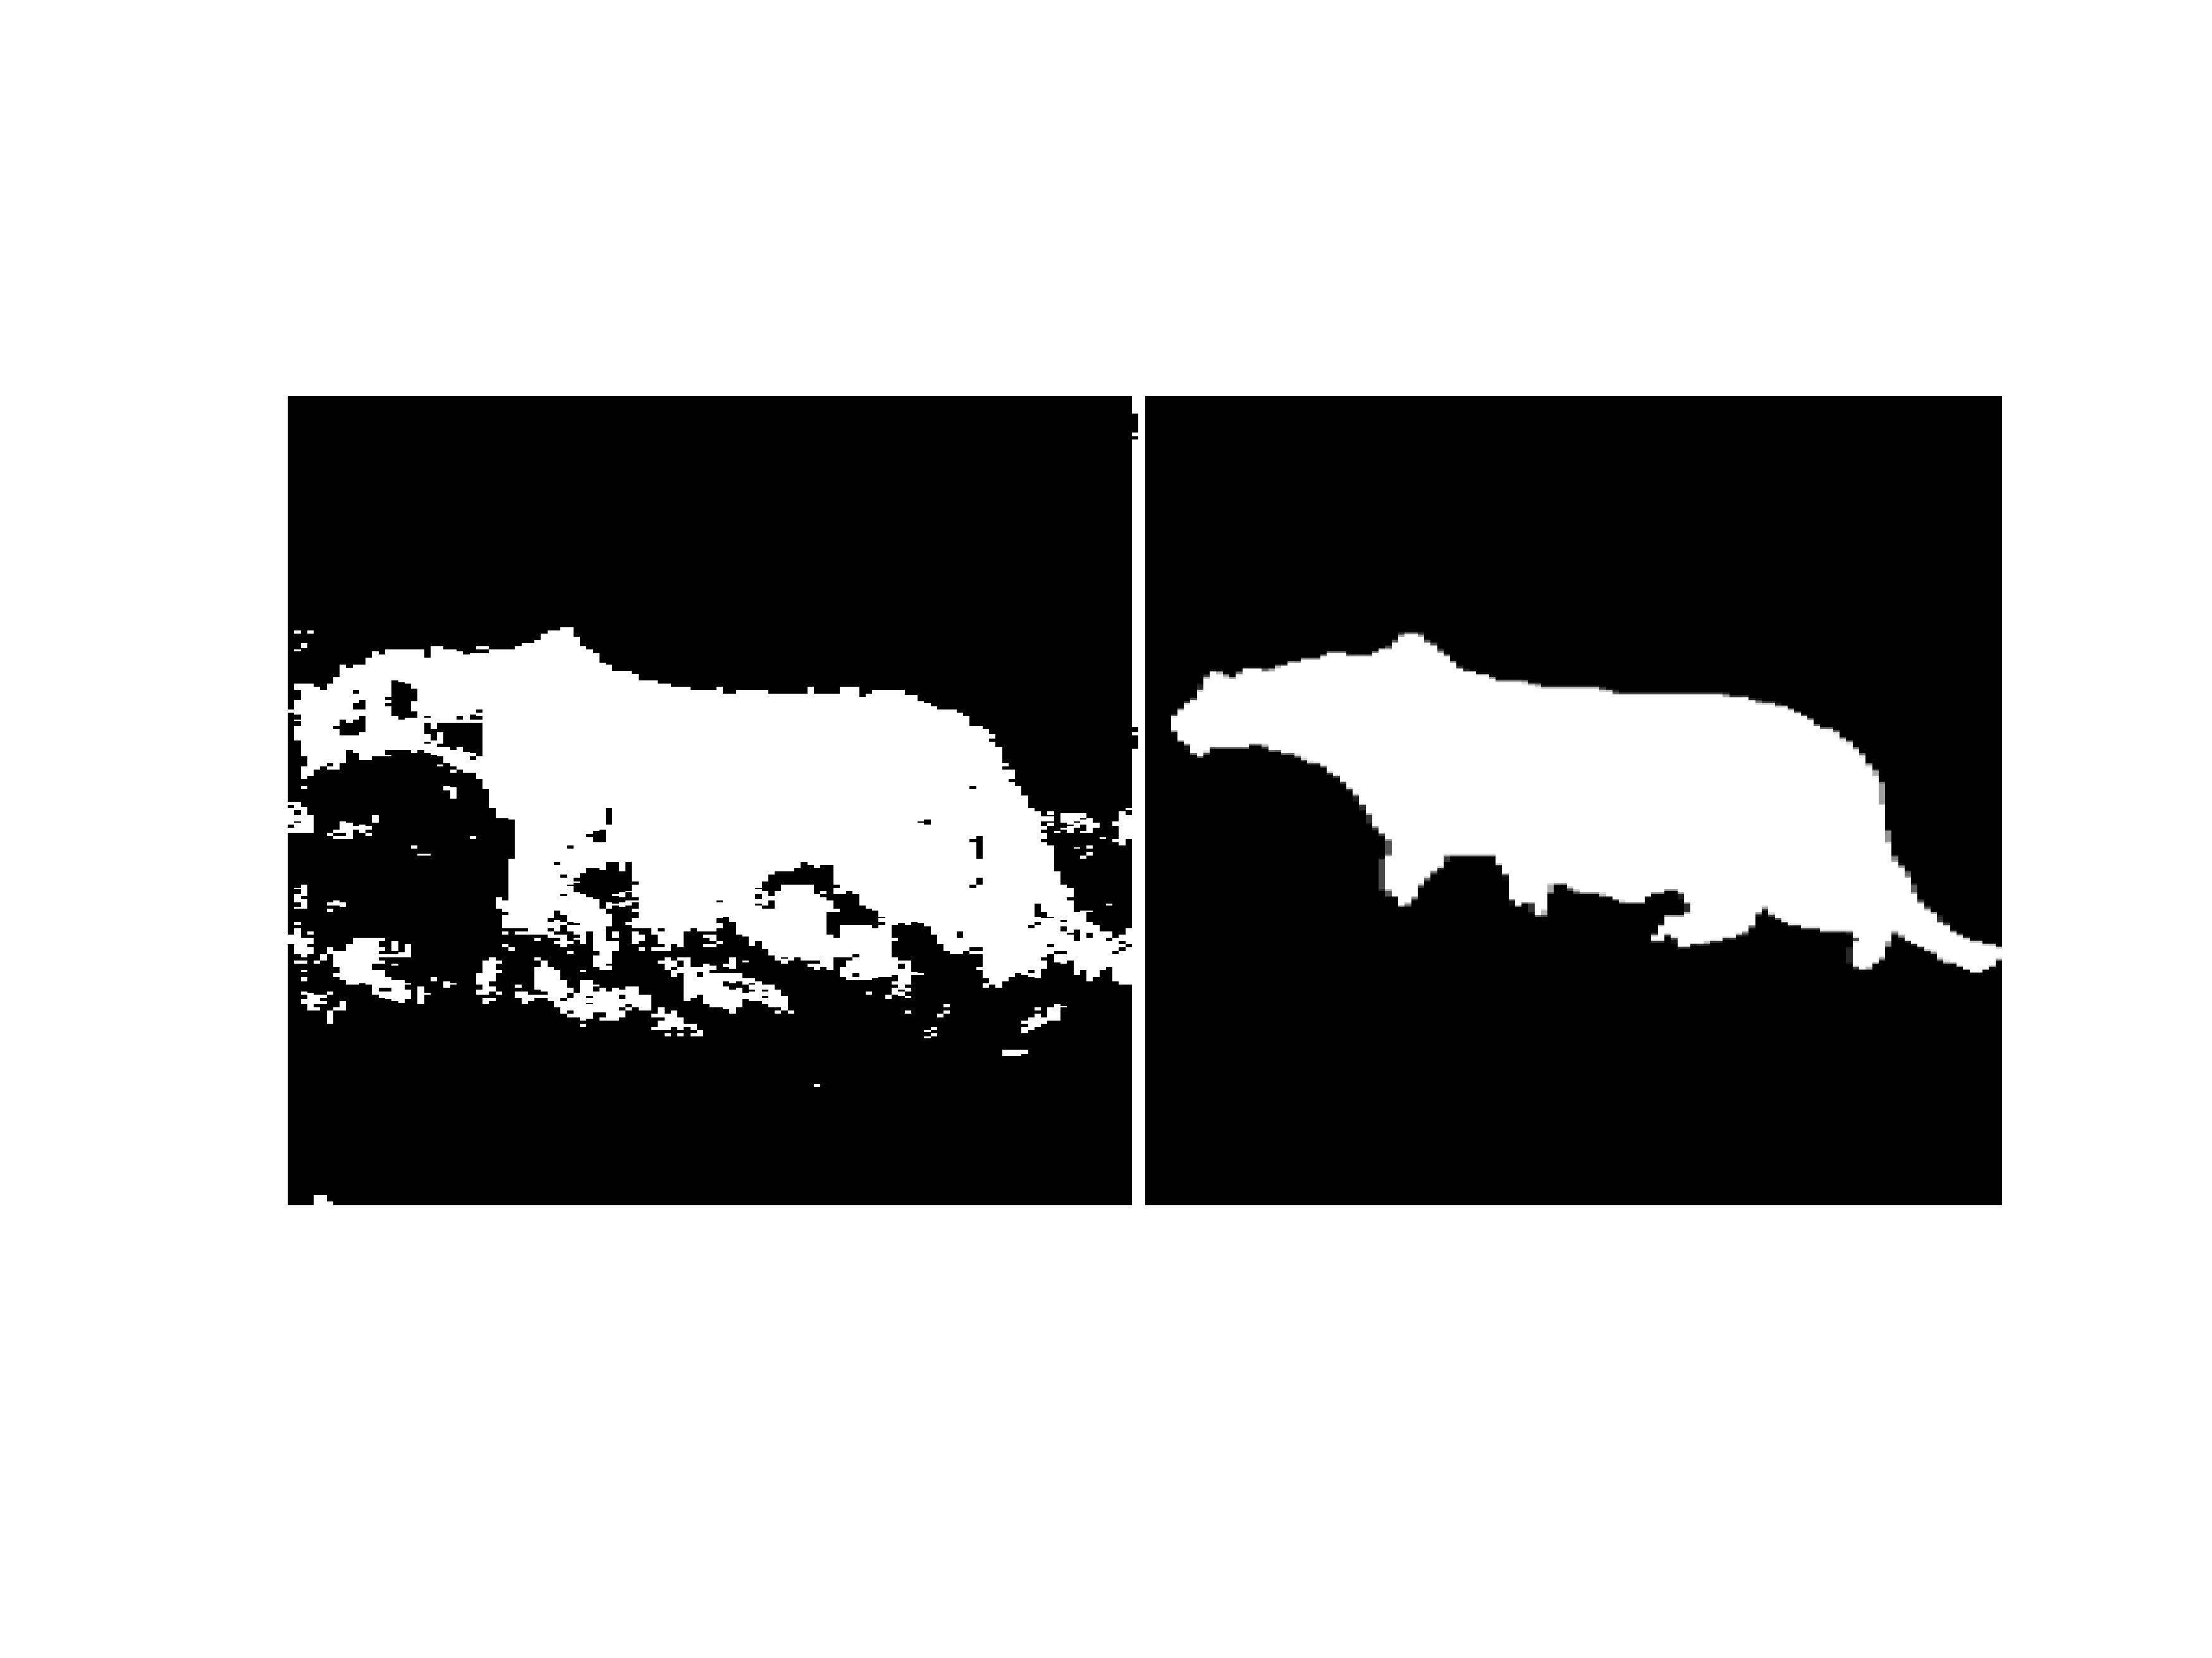

In [19]:
figure
montage({mask,I_ground})


Probability of error of algorithmn


In [20]:
error = sum(abs(mask-I_ground_double),"all")/(size(I_ground,1)*size(I_ground,2))

error = 0.0956


Using the eight best fetures


In [21]:
x_best = X(:,best_features);
x_cheetah_abs_best = x_cheetah_abs(:,best_features);
x_grass_abs_best = x_grass_abs(:,best_features);

[P_cheetah_given_x_prop,P_grass_given_x_prop,Action2] = BDR (x_best,x_cheetah_abs_best,x_grass_abs_best,P_cheetah,P_grass);


Plotting the mask



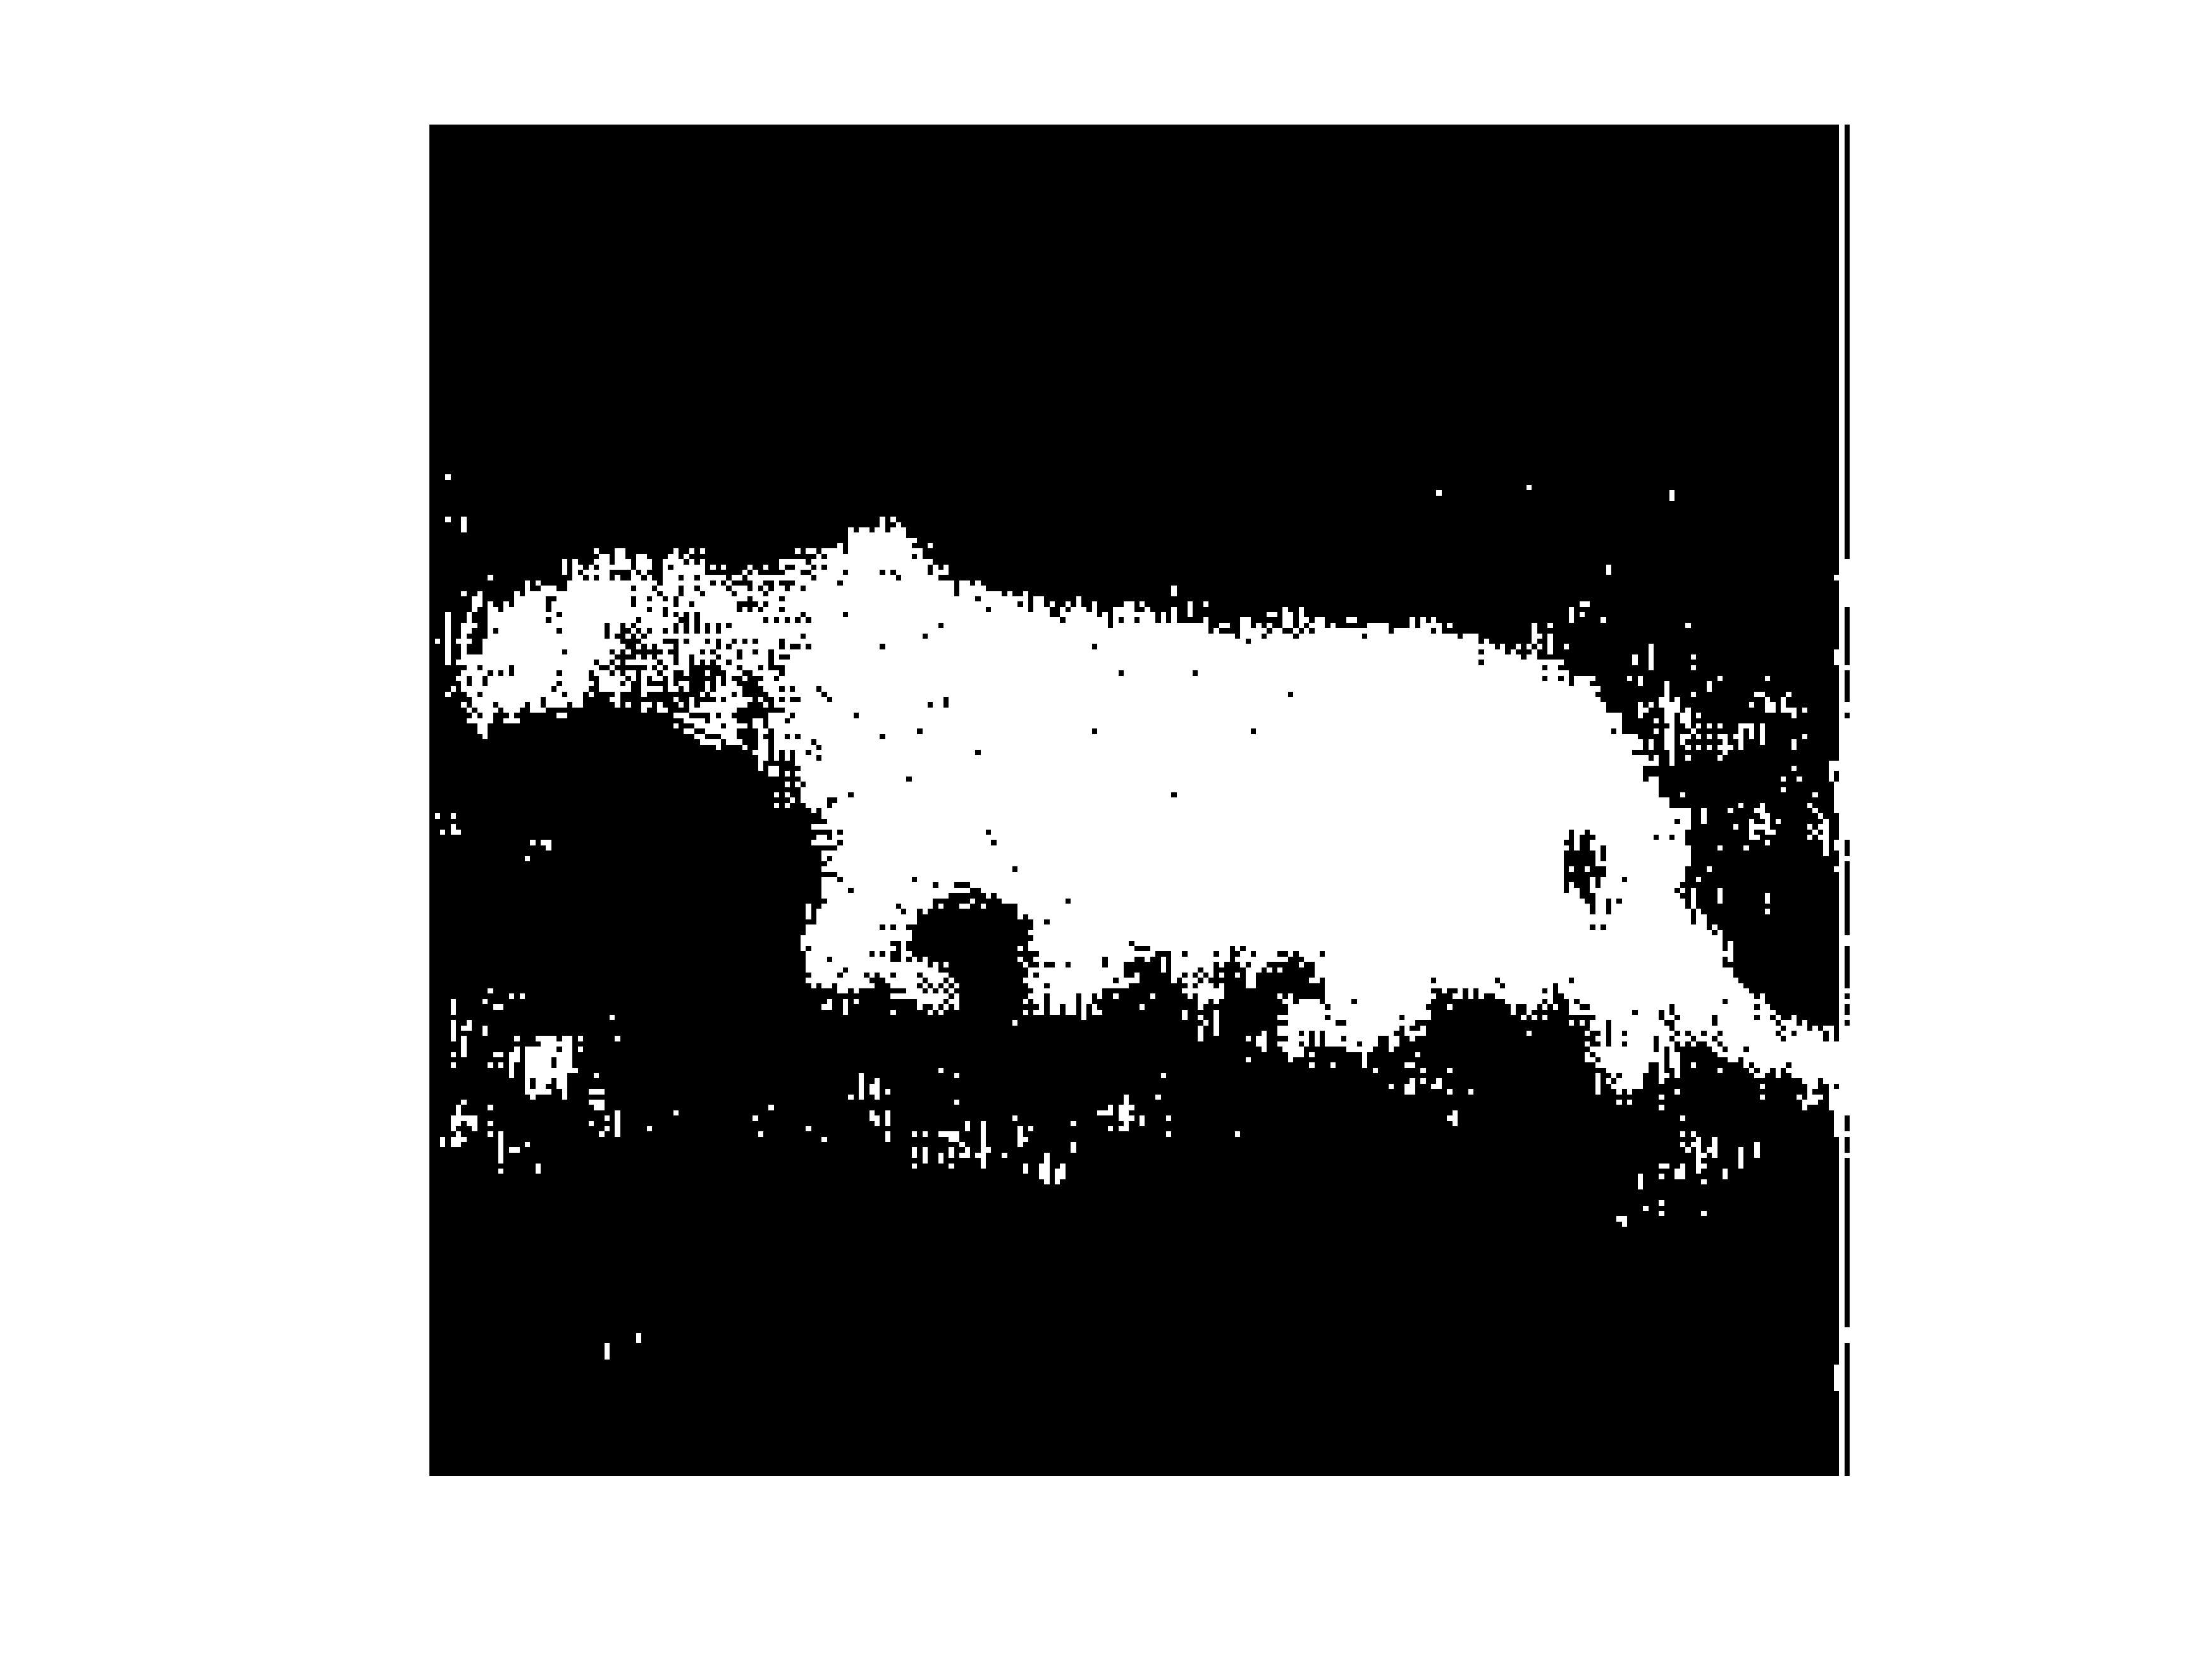

In [22]:
mask = reshape(Action2,size(image,2),[])';
figure
imshow(mask)


Comparison of result with ground truth



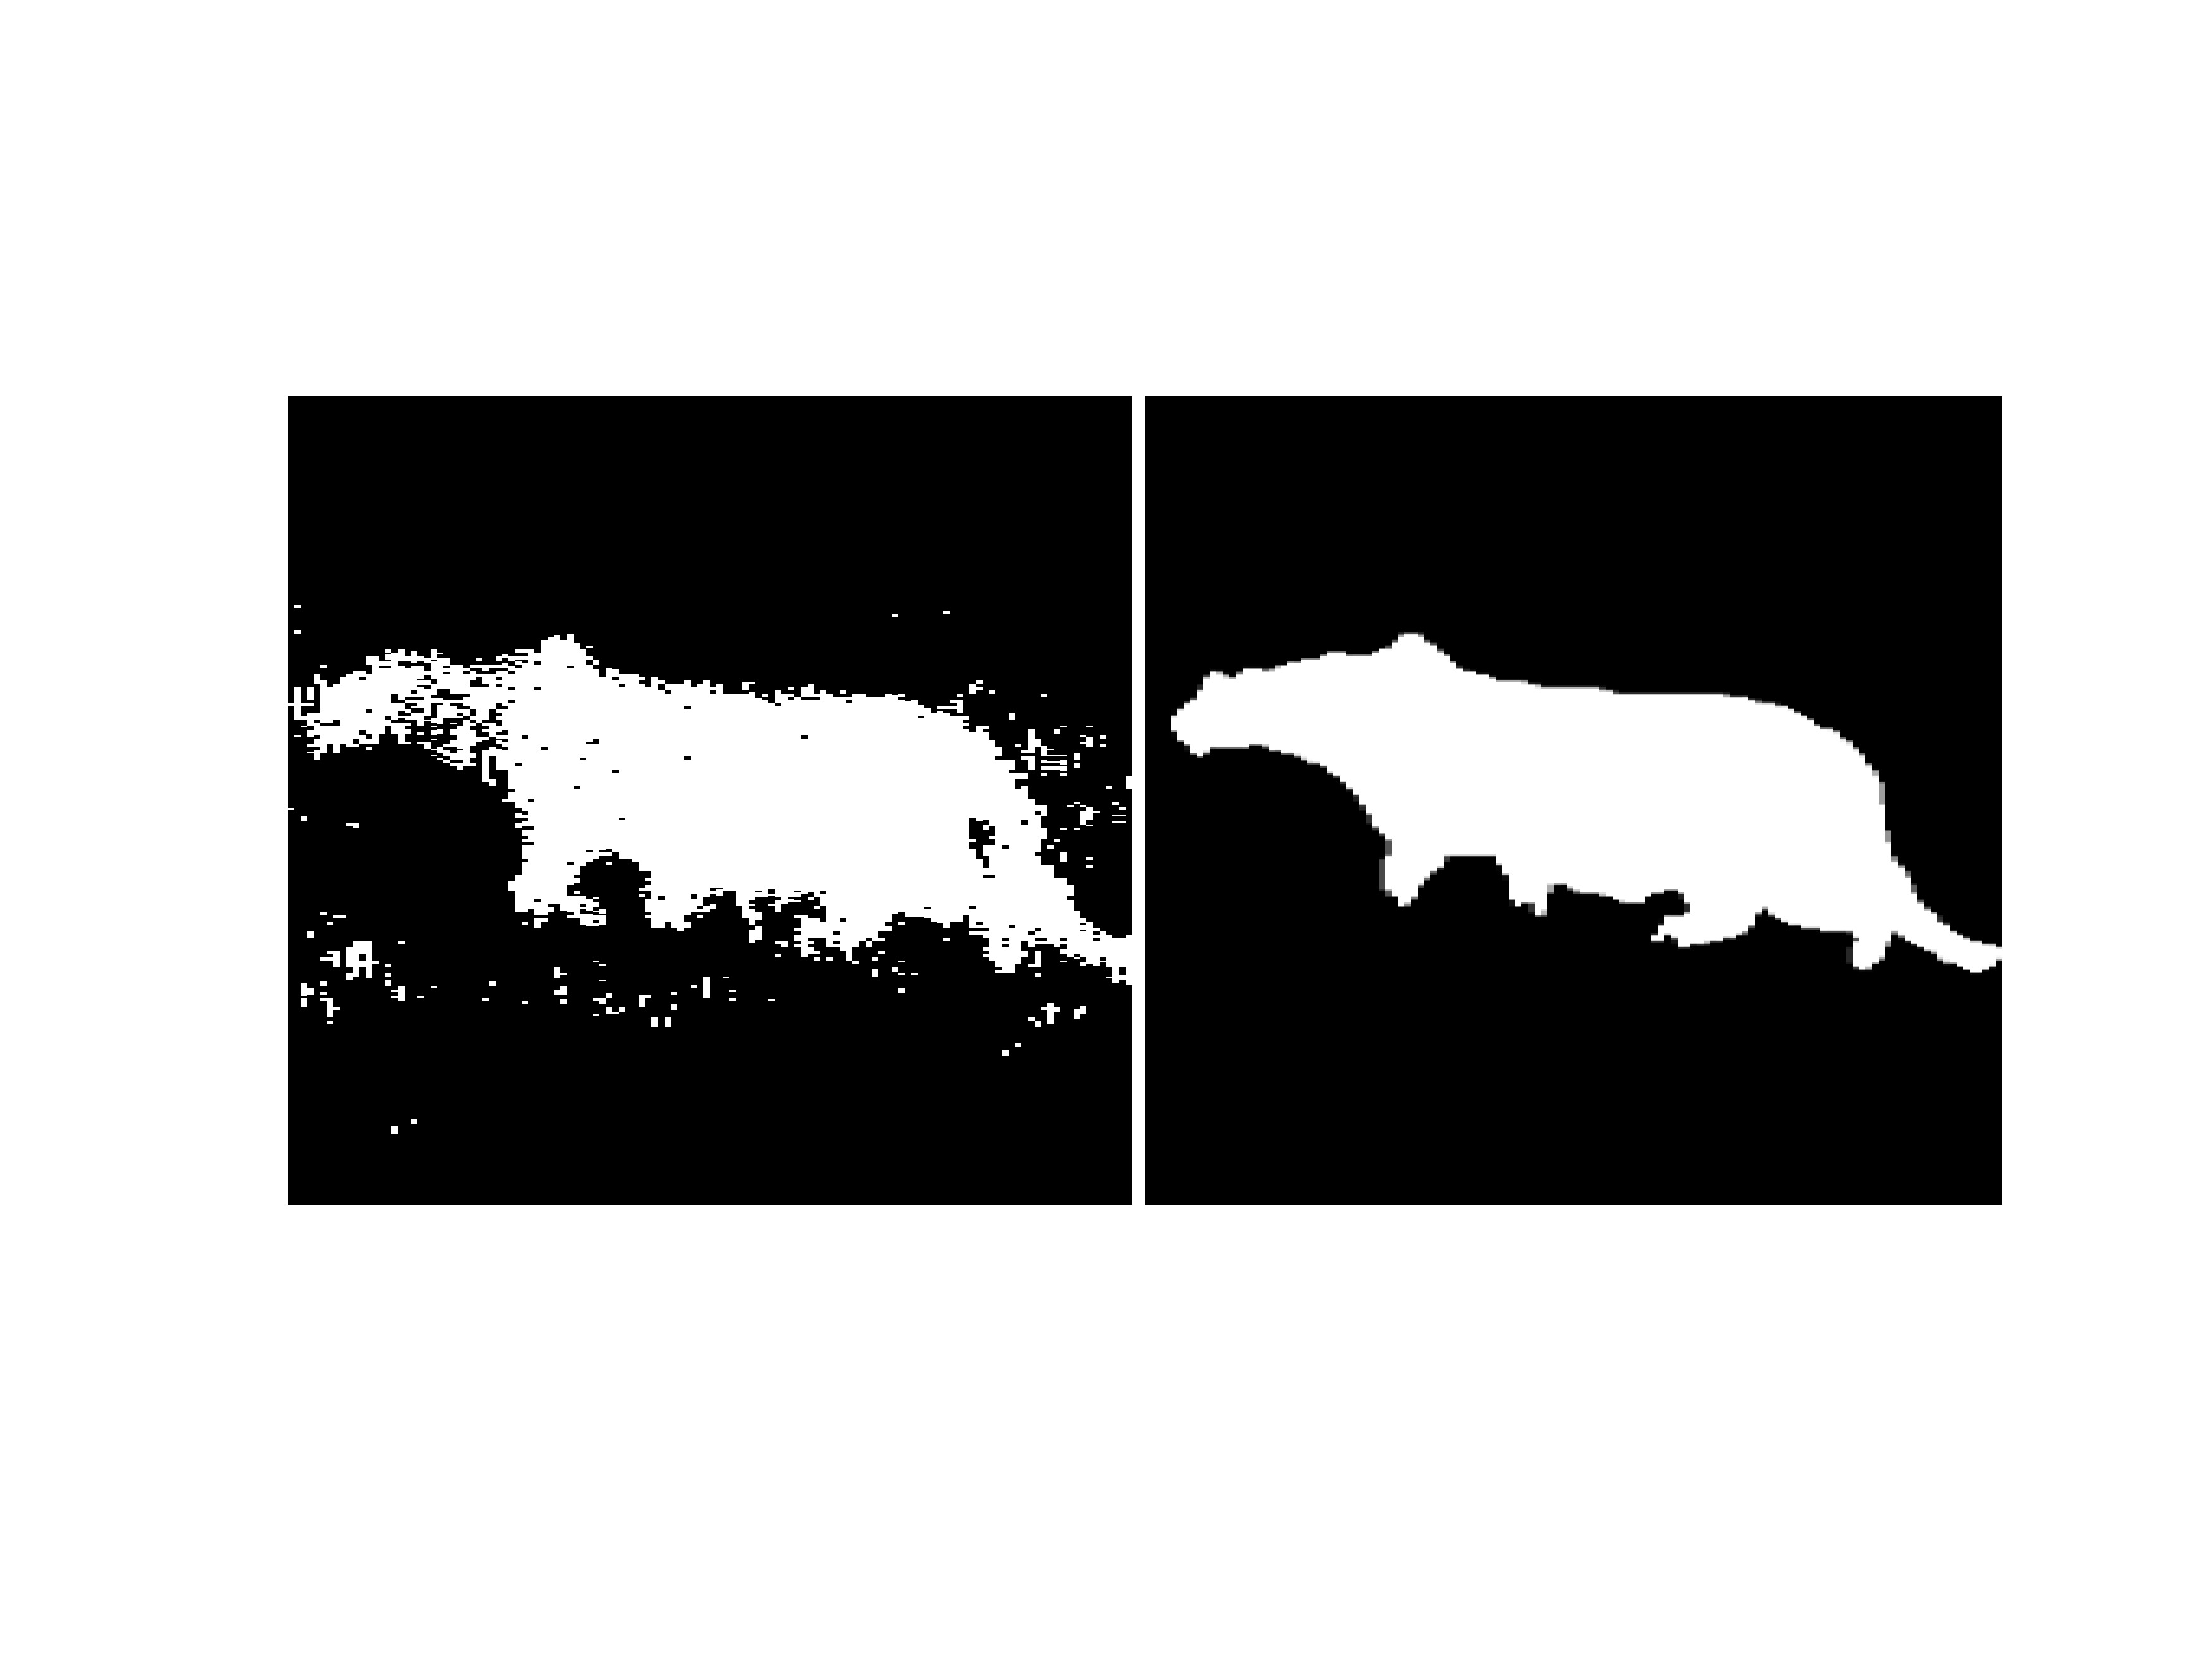

In [23]:
figure
montage({mask,I_ground})


Probability of error of algorithmn


In [24]:
error = sum(abs(mask-I_ground_double),"all")/(size(I_ground,1)*size(I_ground,2))

error = 0.0523


The misclassification error in the case of using best feature is less compared to using all the features, as some features has the chance of misclassfication as seen in the gaussian distribution when prior probabilites are considered. As the dimension of feature increased, the gaussian distribution is not able to fit the underlying distribution properly and data is limited. This is known as **curse of dimensionality** problem. 

